# DATA 612 – Project 1: Global Baseline Predictors and RMSE

Domllermut C.  Alamo



In this first assignment, we’ll attempt to predict ratings with very little information. We’ll first look at just raw averages across all (training dataset) users. We’ll then account for “bias” by normalizing across users and across items.
You’ll be working with ratings in a user-item matrix, where each rating may be (1) assigned to a training dataset, (2) assigned to a test dataset, or (3) missing.

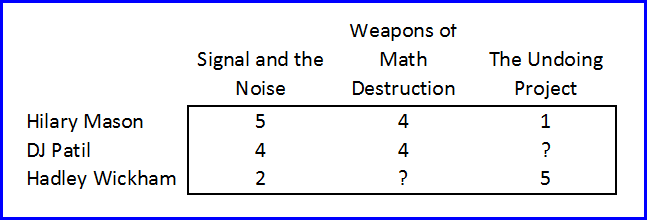

Please code as much of your work as possible in R or Python. You may use standard functions (e.g. from base R and the tidyverse). Your project should be delivered in an R Markdown or a Jupyter notebook, then the notebook should be saved into a GitHub repository. You should include a link to your GitHub repository in your assignment submission link. 

**Preparation.** 

Start by watching Parts K through P from this playlist (https://www.youtube.com/playlist?list=PLuKhJYywjDe96T2L0-zXFU5Up2jqXlWI9) from the Coursera/Stanford Networks Illustrated course (total run time is about 22 minutes):

•Briefly describe the recommender system that you’re going to build out from a businessperspective, e.g. “This system recommends data science books to readers.”

•Find a dataset, or build out your own toy dataset. As a minimum requirement for complexity,please include numeric ratings for at least five users, across at least five items, with some missingdata.

•Load your data into (for example) an R or pandas dataframe, a Python dictionary or list of lists, (oranother data structure of your choosing). From there, create a user-item matrix.

•If you choose to work with a large dataset, you’re encouraged to also create a small, relativelydense “user-item” matrix as a subset so that you can hand-verify your calculations.

•Break your ratings into separate training and test datasets.

•Using your training data, calculate the raw average (mean) rating for every user-item combination.

•Calculate the RMSE for raw average for both your training data and your test data.

•Using your training data, calculate the bias for each user and each item.

•From the raw average, and the appropriate user and item biases, calculate the baseline predictorsfor every user-item combination.

•Calculate the RMSE for the baseline predictors for both your training data and your test data.

•Summarize your results.

## Business Description

This system recommends financial instruments to investors based on their 
risk profile. Users are represented as standardized risk profiles ranging 
from Conservative to Aggressive. Items are a curated mix of bonds, ETFs, 
and equities. Ratings reflect how suitable each instrument is for each 
risk profile, derived from historical return and volatility data. The goal 
is to predict unobserved suitability scores and evaluate prediction quality 
using RMSE, establishing a baseline before any collaborative filtering is applied.

In [72]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\python.exe


In [73]:
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.express as px

## Visualization Setup

Establishing a consistent visual style based on Knaflic's storytelling 
principles and the palette. All charts 
share the same theme, colors, and formatting conventions.

In [74]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# penguin_colors translated from our R palette to Python
penguin_colors = {
    'blue':   '#4e79a7',
    'orange': '#f28e2b',
    'green':  '#59a14f',
    'red':    '#e15759',
    'purple': '#b07aa1',
    'teal':   '#76b7b2',
    'brown':  '#9c755f',
    'yellow': '#edc948',
    'pink':   '#ff9da7',
    'gray':   '#bab0ac'
}

# cool to warm: conservative = blue, aggressive = red
profile_colors = {
    'Conservative':          '#4e79a7',
    'Moderate_Conservative': '#76b7b2',
    'Moderate':              '#59a14f',
    'Moderate_Aggressive':   '#f28e2b',
    'Aggressive':            '#e15759'
}

# dark background colors
bg_color    = '#17202a'
text_color  = '#ecf0f1'
spine_color = '#2d3436'

# knaflic + dark global theme
plt.rcParams.update({
    'figure.facecolor':      bg_color,
    'axes.facecolor':        bg_color,
    'axes.edgecolor':        spine_color,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'axes.titlesize':        13,
    'axes.titleweight':      'bold',
    'axes.titlepad':         14,
    'axes.titlelocation':    'left',
    'axes.labelsize':        11,
    'axes.labelcolor':       text_color,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'xtick.color':           text_color,
    'ytick.color':           text_color,
    'text.color':            text_color,
    'legend.frameon':        False,
    'legend.fontsize':       10,
    'figure.dpi':            150,
    'font.family':           'sans-serif',
    'savefig.bbox':          'tight',
    'savefig.dpi':           150,
    'savefig.facecolor':     bg_color
})

print("Theme and palette loaded.")
print(f"Background: {bg_color}")
print(f"Profiles: {list(profile_colors.keys())}")

Theme and palette loaded.
Background: #17202a
Profiles: ['Conservative', 'Moderate_Conservative', 'Moderate', 'Moderate_Aggressive', 'Aggressive']


## Data Construction

We define five investor risk profiles ranging from Conservative to Aggressive,
each assigned a risk tolerance weight that determines how much return is
rewarded versus how much volatility is penalized. The instrument universe
spans 40 tickers across seven asset classes: fixed income, broad market,
international, sectors, commodities, real estate, and individual equities.
Historical price data is pulled through today using yfinance, ensuring the
model always reflects current market conditions.

In [75]:
# define risk profiles and their weights
## We should  add speculative
risk_profiles = {
    'Conservative':          0.2,
    'Moderate_Conservative': 0.35,
    'Moderate':              0.5,
    'Moderate_Aggressive':   0.65,
    'Aggressive':            0.8
}

# 40 instruments across all major asset classes
## later, we should increase the instruments to almost all tickers

# asset class mapping — defined once, used everywhere
asset_classes = {
    'BND':  'Fixed Income',  'TLT':  'Fixed Income', 'IEF':  'Fixed Income',
    'SHY':  'Fixed Income',  'HYG':  'Fixed Income', 'LQD':  'Fixed Income',
    'EMB':  'Fixed Income',  'TIP':  'Fixed Income', 'MUB':  'Fixed Income',
    'SPY':  'Broad Market',  'VTI':  'Broad Market', 'QQQ':  'Broad Market',
    'IWM':  'Broad Market',  'DIA':  'Broad Market', 'VTV':  'Broad Market',
    'VUG':  'Broad Market',
    'VEA':  'International', 'VWO':  'International','EFA':  'International',
    'EEM':  'International',
    'XLK':  'Sectors',       'XLF':  'Sectors',      'XLE':  'Sectors',
    'XLV':  'Sectors',       'XLU':  'Sectors',      'XLP':  'Sectors',
    'XLI':  'Sectors',
    'GLD':  'Commodities',   'SLV':  'Commodities',  'USO':  'Commodities',
    'VNQ':  'Real Estate',   'XLRE': 'Real Estate',
    'AAPL': 'Equities',      'MSFT': 'Equities',     'GOOGL':'Equities',
    'AMZN': 'Equities',      'NVDA': 'Equities',     'TSLA': 'Equities',
    'JPM':  'Equities',      'JNJ':  'Equities'
}

# derive tickers from asset_classes — single source of truth
tickers = list(asset_classes.keys())



# pull 3 years of historical data
raw_data = yf.download(tickers, start='2021-01-01', end = pd.Timestamp.today(), auto_adjust=True)
prices = raw_data['Close']
print(prices.shape)
print(prices.head())

[*********************100%***********************]  40 of 40 completed


(1365, 40)
Ticker            AAPL        AMZN        BND         DIA        EEM  \
Date                                                                   
2021-01-04  125.740860  159.331497  74.396896  275.436218  46.271252   
2021-01-05  127.295456  160.925507  74.270203  276.821045  47.383537   
2021-01-06  123.010529  156.919006  73.940758  280.802490  46.983116   
2021-01-07  127.208054  158.108002  73.788689  282.888824  47.428032   
2021-01-08  128.305984  159.134995  73.721092  283.380676  48.682697   

Ticker            EFA        EMB         GLD      GOOGL        HYG  ...  \
Date                                                                ...   
2021-01-04  62.786316  88.588875  182.330002  85.547935  64.973381  ...   
2021-01-05  63.436939  88.650383  182.869995  86.237808  64.995758  ...   
2021-01-06  64.164642  88.012459  179.899994  85.386856  64.876411  ...   
2021-01-07  64.233124  87.981773  179.479996  87.937233  65.062897  ...   
2021-01-08  64.832405  88.027863  

In [76]:
# compute daily returns
daily_returns = prices.pct_change().dropna()

# annualized return and volatility (252 trading days per year)
annualized_return = daily_returns.mean() * 252
annualized_volatility = daily_returns.std() * np.sqrt(252)

# quick sanity check
stats = pd.DataFrame({
    'annualized_return': annualized_return,
    'annualized_volatility': annualized_volatility
}).round(4)

print(stats)

        annualized_return  annualized_volatility
Ticker                                          
AAPL               0.1939                 0.2760
AMZN               0.1349                 0.3475
BND               -0.0020                 0.0587
DIA                0.1214                 0.1463
EEM                0.0809                 0.1927
EFA                0.1024                 0.1630
EMB                0.0182                 0.0964
GLD                0.1494                 0.1792
GOOGL              0.3123                 0.3111
HYG                0.0400                 0.0733
IEF               -0.0159                 0.0753
IWM                0.1076                 0.2272
JNJ                0.1200                 0.1679
JPM                0.2222                 0.2425
LQD               -0.0030                 0.0852
MSFT               0.1553                 0.2638
MUB                0.0098                 0.0395
NVDA               0.6358                 0.5124
QQQ                0

In [77]:
# compute raw suitability score for each profile-instrument pair
raw_scores = {}

for profile, weight in risk_profiles.items():
    raw_scores[profile] = (
        weight * annualized_return
        - (1 - weight) * annualized_volatility
    )

scores_df = pd.DataFrame(raw_scores, index=tickers).T

# scale scores to 1-5 using min-max scaling
score_min = scores_df.min().min()
score_max = scores_df.max().max()

scaled_df = 1 + 4 * (scores_df - score_min) / (score_max - score_min)

# conservative: skips individual stocks, growth etfs,
# emerging markets, aggressive sectors, and commodities
scaled_df.loc['Conservative', [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA', 'JPM', 'JNJ',
    'VUG', 'IWM', 'XLK', 'XLE', 'VWO', 'EEM', 'SLV', 'USO',
    'HYG', 'EMB'
]] = np.nan

# moderate conservative: skips volatile stocks,
# emerging markets, commodities, energy
scaled_df.loc['Moderate_Conservative', [
    'TSLA', 'NVDA', 'AMZN', 'GOOGL',
    'VWO', 'EEM', 'SLV', 'USO', 'XLE'
]] = np.nan

# moderate: skips only the most extreme instruments
scaled_df.loc['Moderate', ['TSLA', 'SLV', 'USO', 'VWO']] = np.nan

# moderate aggressive: skips very conservative fixed income
scaled_df.loc['Moderate_Aggressive', ['SHY', 'MUB', 'TIP', 'USO']] = np.nan

# aggressive: skips short-duration and conservative bonds
scaled_df.loc['Aggressive', ['SHY', 'MUB', 'TIP', 'IEF', 'LQD']] = np.nan

print(scaled_df.round(2))

                        BND   TLT   IEF   SHY   HYG   LQD   EMB   TIP   MUB  \
Conservative           2.81  2.37  2.74  2.98   NaN  2.71   NaN  2.82  2.90   
Moderate_Conservative  2.85  2.43  2.78  3.01  2.88  2.77  2.77  2.87  2.93   
Moderate               2.89  2.50  2.82  3.03  2.96  2.83  2.85  2.92  2.97   
Moderate_Aggressive    2.94  2.56  2.86   NaN  3.04  2.89  2.94   NaN   NaN   
Aggressive             2.98  2.62   NaN   NaN  3.12   NaN  3.02   NaN   NaN   

                        SPY  ...   VNQ  XLRE  AAPL  MSFT  GOOGL  AMZN  NVDA  \
Conservative           2.54  ...  2.41  2.41   NaN   NaN    NaN   NaN   NaN   
Moderate_Conservative  2.77  ...  2.60  2.61  2.50  2.48    NaN   NaN   NaN   
Moderate               3.00  ...  2.80  2.82  2.84  2.78   3.04  2.53  3.34   
Moderate_Aggressive    3.24  ...  3.00  3.02  3.18  3.08   3.49  2.88  4.17   
Aggressive             3.47  ...  3.19  3.22  3.52  3.39   3.95  3.23  5.00   

                       TSLA   JPM   JNJ  
Conserva

## Instrument Inclusion by Risk Profile

Not every profile evaluates every instrument. The matrix below shows 
which instruments fall within each profile's evaluation universe. 
Green = evaluated, dark = excluded. The near-nested structure confirms 
that conservative profiles operate within a strict subset of the full 
instrument universe.

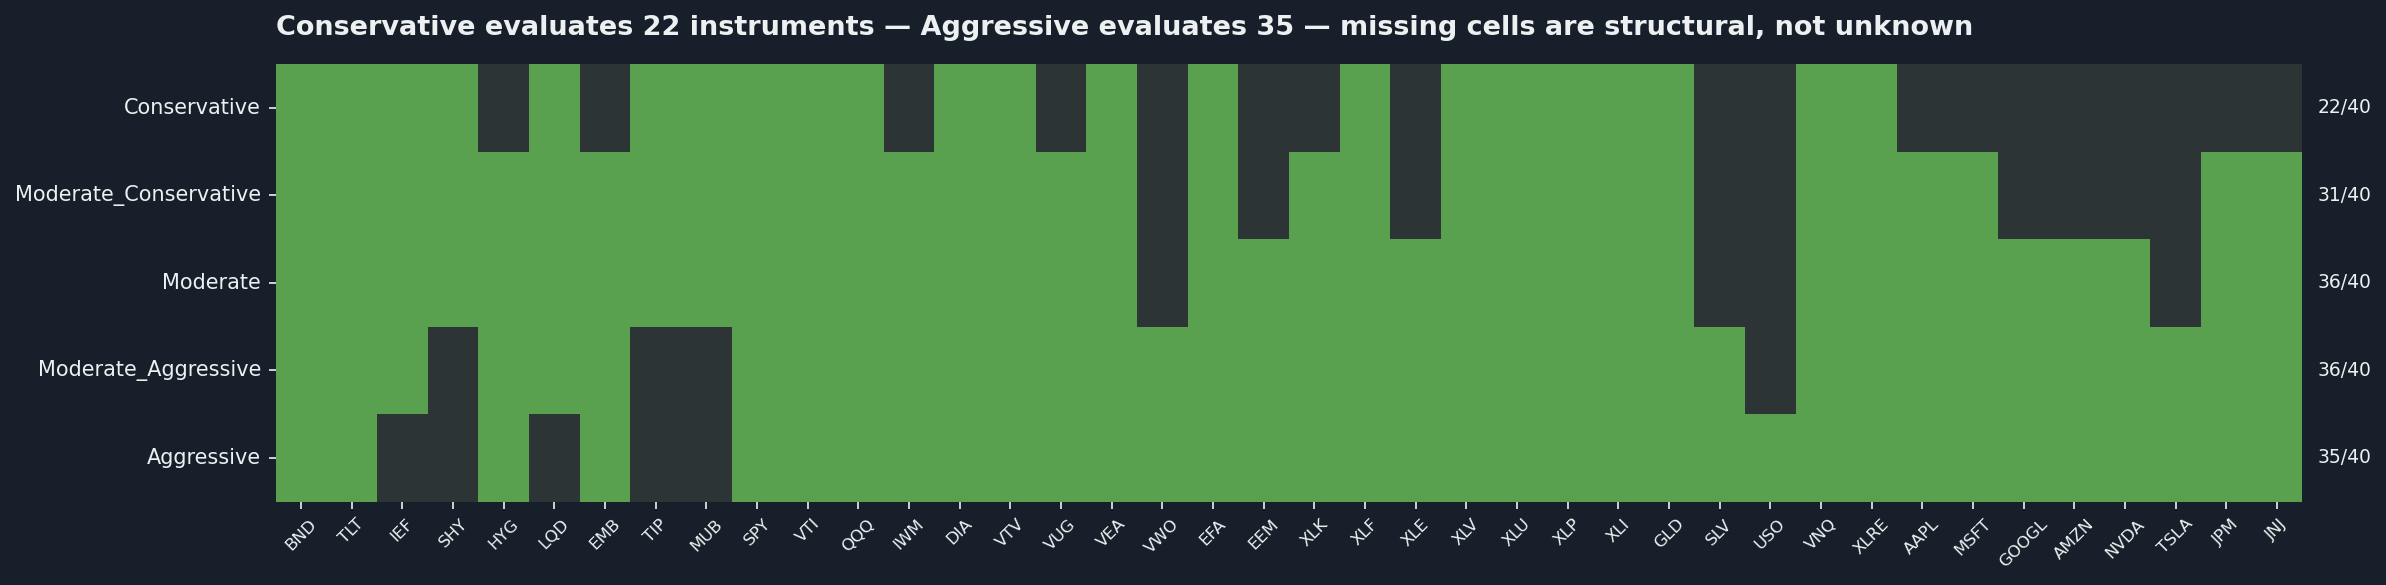

In [98]:
# binary inclusion matrix: 1 = evaluated, 0 = excluded
inclusion = scaled_df.notna().astype(int)

fig, ax = plt.subplots(figsize=(16, 4))

# custom two-color palette
cmap = sns.color_palette([spine_color, penguin_colors['green']], as_cmap=True)

sns.heatmap(
    inclusion,
    cmap=cmap,
    linewidths=0,
    cbar=False,
    ax=ax,
    annot=False
)

# add column counts as annotation on right side
for i, profile in enumerate(inclusion.index):
    count = inclusion.loc[profile].sum()
    ax.text(
        len(tickers) + 0.3, i + 0.5,
        f'{count}/{len(tickers)}',
        va='center', ha='left',
        fontsize=9, color=text_color
    )

ax.set_title(
    'Conservative evaluates 22 instruments — '
    'Aggressive evaluates 35 — '
    'missing cells are structural, not unknown',
    fontweight='bold', loc='left'
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0)
ax.set_xlabel('')
ax.set_ylabel('')
ax.grid(False)

plt.tight_layout()
plt.savefig('output/inclusion_matrix.png')
plt.show()

## Train/Test Split

Observed ratings are split 80/20 into training and test sets. Biases and 
the global mean are computed exclusively from training data. Both sets are 
evaluated for RMSE. A random seed ensures reproducibility.

In [ ]:
np.random.seed(612)

# collect all observed ratings as (user, item) pairs
observed = [
    (user, item)
    for user in scaled_df.index
    for item in scaled_df.columns
    if not pd.isna(scaled_df.loc[user, item])
]

# shuffle and split 80/20
np.random.shuffle(observed)
split = int(len(observed) * 0.8)
train_pairs = observed[:split]
test_pairs = observed[split:]

# build train and test matrices (NaN everywhere except observed split)
train_matrix = pd.DataFrame(np.nan, index=scaled_df.index, columns=scaled_df.columns)
test_matrix = pd.DataFrame(np.nan, index=scaled_df.index, columns=scaled_df.columns)

# populate train matrix: only ratings assigned to training split
for user, item in train_pairs:
    train_matrix.loc[user, item] = scaled_df.loc[user, item]

# populate test matrix: only ratings assigned to test split
# these ratings are held out and never seen during training
for user, item in test_pairs:
    test_matrix.loc[user, item] = scaled_df.loc[user, item]

print(f"Total observed ratings: {len(observed)}")
print(f"Training ratings:       {len(train_pairs)}")
print(f"Test ratings:           {len(test_pairs)}")
print()
print("Training matrix:")
print(train_matrix.round(2))

Total observed ratings: 160
Training ratings:       128
Test ratings:           32

Training matrix:
                        BND   TLT   IEF   SHY   HYG   LQD   EMB   TIP   MUB  \
Conservative           2.81   NaN  2.74  2.98   NaN  2.71   NaN  2.82  2.90   
Moderate_Conservative  2.85  2.43  2.78  3.01  2.88   NaN   NaN   NaN  2.93   
Moderate               2.89  2.50  2.82  3.03   NaN  2.83  2.85  2.92  2.97   
Moderate_Aggressive    2.94  2.56  2.86   NaN  3.04  2.89  2.94   NaN   NaN   
Aggressive             2.98  2.62   NaN   NaN   NaN   NaN  3.02   NaN   NaN   

                        SPY  ...   VNQ  XLRE  AAPL  MSFT  GOOGL  AMZN  NVDA  \
Conservative           2.54  ...  2.41  2.41   NaN   NaN    NaN   NaN   NaN   
Moderate_Conservative  2.77  ...  2.60  2.61  2.50  2.48    NaN   NaN   NaN   
Moderate               3.00  ...  2.80   NaN  2.84   NaN    NaN  2.53  3.34   
Moderate_Aggressive    3.24  ...  3.00  3.02  3.18  3.08   3.49  2.88  4.17   
Aggressive             3.47  

## Hand Verification. Toy Subset

Before applying the model to the full 40-instrument universe, we verify 
our calculations on a small dense 3×4 subset. This allows us to confirm 
that the global mean, user bias, item bias, and baseline predictor are 
computed correctly by checking the math manually.

In [100]:
# 3 profiles x 4 instruments, dense enough to verify by hand
toy_data = {
    'SPY':  {'Conservative': 2.59, 'Moderate': 3.03, 'Aggressive': 3.47},
    'QQQ':  {'Conservative': np.nan,'Moderate': 3.15, 'Aggressive': 4.76},
    'BND':  {'Conservative': 2.89, 'Moderate': 2.94, 'Aggressive': 2.99},
    'NVDA': {'Conservative': np.nan,'Moderate': 3.32, 'Aggressive': 4.54}
}

toy_matrix = pd.DataFrame(toy_data)
print("Toy user-item matrix:")
print(toy_matrix.round(2))

# global mean
toy_mean = toy_matrix.stack().mean()
print(f"\nGlobal mean (μ): {toy_mean:.4f}")
print(f"Hand check: sum of observed = "
      f"{toy_matrix.stack().sum():.4f} / "
      f"{toy_matrix.stack().count()} ratings = "
      f"{toy_matrix.stack().mean():.4f}")

# user bias
toy_user_bias = toy_matrix.mean(axis=1) - toy_mean
print("\nUser bias (b_u):")
for user, bias in toy_user_bias.items():
    user_mean = toy_matrix.loc[user].mean()
    print(f"  {user:20s}: {user_mean:.4f} - {toy_mean:.4f} = {bias:.4f}")

# item bias
toy_item_bias = toy_matrix.mean(axis=0) - toy_mean
print("\nItem bias (b_i):")
for item, bias in toy_item_bias.items():
    item_mean = toy_matrix[item].mean()
    print(f"  {item:6s}: {item_mean:.4f} - {toy_mean:.4f} = {bias:.4f}")

# baseline predictor for all pairs
print("\nBaseline predictor (μ + b_u + b_i):")
print(f"{'':20s}", end='')
for item in toy_matrix.columns:
    print(f"  {item:6s}", end='')
print()

for user in toy_matrix.index:
    print(f"{user:20s}", end='')
    for item in toy_matrix.columns:
        pred = np.clip(
            toy_mean + toy_user_bias[user] + toy_item_bias[item],
            1, 5
        )
        actual = toy_matrix.loc[user, item]
        marker = '*' if pd.isna(actual) else ' '
        print(f"  {pred:.2f}{marker} ", end='')
    print()

print("\n* = missing in original matrix, predicted by baseline")

# RMSE on toy subset
toy_errors = []
for user in toy_matrix.index:
    for item in toy_matrix.columns:
        actual = toy_matrix.loc[user, item]
        if not pd.isna(actual):
            pred = np.clip(
                toy_mean + toy_user_bias[user] + toy_item_bias[item],
                1, 5
            )
            toy_errors.append((actual - pred) ** 2)

toy_rmse = np.sqrt(np.mean(toy_errors))
toy_raw_rmse = np.sqrt(np.mean([
    (toy_matrix.stack().values[i] - toy_mean) ** 2
    for i in range(len(toy_matrix.stack()))
]))

print(f"\nToy RMSE — raw average:        {toy_raw_rmse:.4f}")
print(f"Toy RMSE — baseline predictor: {toy_rmse:.4f}")
print(f"Improvement: "
      f"{(toy_raw_rmse - toy_rmse) / toy_raw_rmse * 100:.1f}%")

Toy user-item matrix:
               SPY   QQQ   BND  NVDA
Conservative  2.59   NaN  2.89   NaN
Moderate      3.03  3.15  2.94  3.32
Aggressive    3.47  4.76  2.99  4.54

Global mean (μ): 3.3680
Hand check: sum of observed = 33.6800 / 10 ratings = 3.3680

User bias (b_u):
  Conservative        : 2.7400 - 3.3680 = -0.6280
  Moderate            : 3.1100 - 3.3680 = -0.2580
  Aggressive          : 3.9400 - 3.3680 = 0.5720

Item bias (b_i):
  SPY   : 3.0300 - 3.3680 = -0.3380
  QQQ   : 3.9550 - 3.3680 = 0.5870
  BND   : 2.9400 - 3.3680 = -0.4280
  NVDA  : 3.9300 - 3.3680 = 0.5620

Baseline predictor (μ + b_u + b_i):
                      SPY     QQQ     BND     NVDA  
Conservative          2.40    3.33*   2.31    3.30* 
Moderate              2.77    3.70    2.68    3.67  
Aggressive            3.60    4.53    3.51    4.50  

* = missing in original matrix, predicted by baseline

Toy RMSE — raw average:        0.6816
Toy RMSE — baseline predictor: 0.3566
Improvement: 47.7%


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning:

All-NaN slice encountered

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning:

All-NaN slice encountered



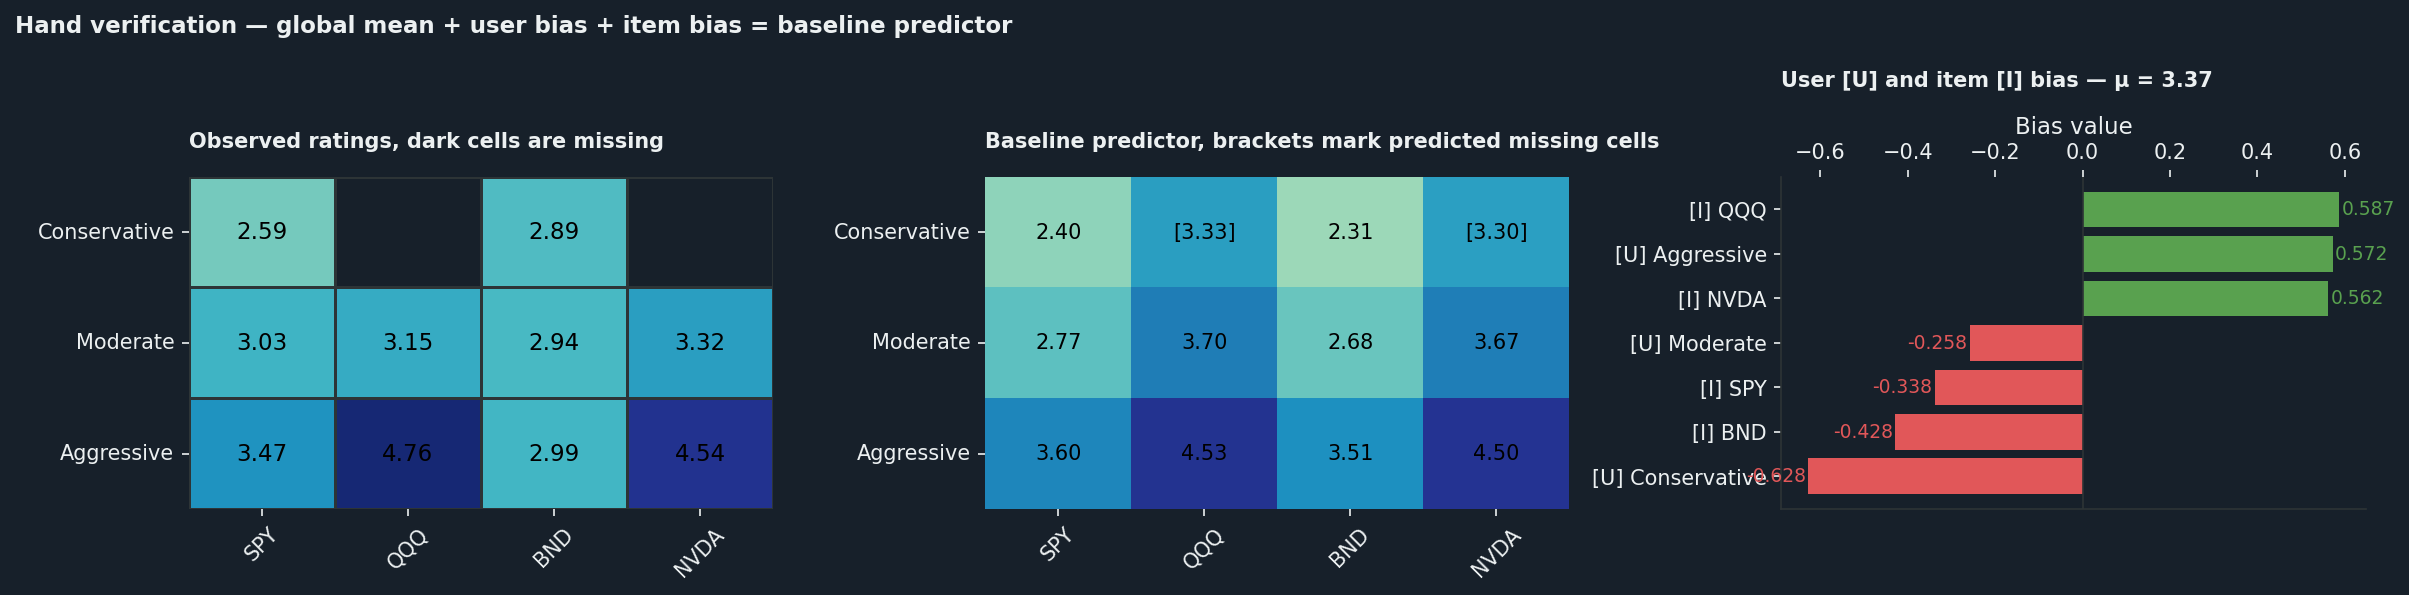

In [101]:
bg_color   = '#17202a'
text_color = '#ecf0f1'
spine_color = '#2d3436'

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=bg_color)

for ax in axes:
    ax.set_facecolor(bg_color)
    ax.tick_params(colors=text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(spine_color)

# ── LEFT: original toy matrix ─────────────────────────────────
mask_toy = toy_matrix.isnull()

sns.heatmap(
    toy_matrix,
    mask=mask_toy,
    annot=True, fmt='.2f',
    cmap='YlGnBu',
    vmin=1, vmax=5,
    linewidths=0.5,
    linecolor=spine_color,
    cbar=False,
    ax=axes[0],
    annot_kws={'size': 11, 'color': 'black'}
)
sns.heatmap(
    toy_matrix,
    mask=~mask_toy,
    annot=False,
    cmap=['#2d3436'],
    cbar=False,
    linewidths=0.5,
    linecolor=spine_color,
    ax=axes[0]
)
axes[0].set_title(
    'Observed ratings, dark cells are missing',
    fontweight='bold', loc='left',
    fontsize=10, color=text_color
)
axes[0].tick_params(axis='x', rotation=45, colors=text_color)
axes[0].tick_params(axis='y', rotation=0, colors=text_color)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].grid(False)

# ── MIDDLE: baseline predictor ────────────────────────────────
toy_baseline = pd.DataFrame(
    index=toy_matrix.index,
    columns=toy_matrix.columns,
    dtype=float
)
for user in toy_matrix.index:
    for item in toy_matrix.columns:
        toy_baseline.loc[user, item] = np.clip(
            toy_mean + toy_user_bias[user] + toy_item_bias[item],
            1, 5
        )

annot_matrix = toy_baseline.copy().astype(str)
for user in toy_matrix.index:
    for item in toy_matrix.columns:
        val = f"{toy_baseline.loc[user, item]:.2f}"
        annot_matrix.loc[user, item] = (
            f"[{val}]" if pd.isna(toy_matrix.loc[user, item]) else val
        )

sns.heatmap(
    toy_baseline.astype(float),
    annot=annot_matrix,
    fmt='',
    cmap='YlGnBu',
    vmin=1, vmax=5,
    linewidths=0,
    linecolor=spine_color,
    cbar=False,
    ax=axes[1],
    annot_kws={'size': 10, 'color': 'black'}
)
axes[1].set_title(
    'Baseline predictor, brackets mark predicted missing cells',
    fontweight='bold', loc='left',
    fontsize=10, color=text_color
)
axes[1].tick_params(axis='x', rotation=45, colors=text_color)
axes[1].tick_params(axis='y', rotation=0, colors=text_color)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].grid(False)

# ── RIGHT: bias bar chart (Knaflic) ───────────────────────────
ax = axes[2]
ax.set_facecolor(bg_color)

bias_combined = pd.concat([
    toy_user_bias.rename(lambda x: f'[U] {x}'),
    toy_item_bias.rename(lambda x: f'[I] {x}')
]).sort_values()

colors = [
    penguin_colors['red'] if v < 0 else penguin_colors['green']
    for v in bias_combined.values
]

ax.barh(bias_combined.index, bias_combined.values, color=colors)
ax.axvline(0, color=spine_color, linewidth=0.8)
ax.grid(False)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(colors=text_color)
ax.set_xlabel('Bias value', color=text_color)

for i, val in enumerate(bias_combined.values):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        i, f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9,
        color=penguin_colors['green'] if val >= 0 else penguin_colors['red']
    )

ax.set_title(
    f'User [U] and item [I] bias — μ = {toy_mean:.2f}',
    fontweight='bold', loc='left',
    fontsize=10, color=text_color
)

fig.suptitle(
    'Hand verification — global mean + user bias + item bias = baseline predictor',
    fontweight='bold', x=0, ha='left',
    fontsize=11, color=text_color
)

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.15)
plt.tight_layout()
plt.savefig(
    'output/hand_verification.png',
    facecolor=bg_color, bbox_inches='tight'
)
plt.show()

## Raw Average Prediction

The simplest possible predictor: use the global mean of all training 
ratings to predict every user-item combination. This ignores everything 
we know about individual users and items.

In [102]:
# global mean from training data only
global_mean = train_matrix.stack().mean()
print(f"Global mean (μ): {global_mean:.4f}")

# predict every pair using global mean
def compute_rmse(matrix, prediction):
    observed = matrix.stack()
    errors = observed - prediction
    return np.sqrt((errors ** 2).mean())

rmse_raw_train = compute_rmse(train_matrix, global_mean)
rmse_raw_test = compute_rmse(test_matrix, global_mean)

print(f"RMSE raw average (train): {rmse_raw_train:.4f}")
print(f"RMSE raw average (test):  {rmse_raw_test:.4f}")

Global mean (μ): 2.9837
RMSE raw average (train): 0.3751
RMSE raw average (test):  0.3669


## User and Item Bias

User bias captures how much each risk profile rates above or below the 
global mean. Item bias captures how much each instrument is rated above 
or below the global mean, regardless of who is rating it.

- b_u = mean(ratings by user u) − μ  
- b_i = mean(ratings of item i) − μ

In [103]:
# user bias: how much each profile deviates from global mean
user_bias = train_matrix.mean(axis=1) - global_mean

# item bias: how much each instrument deviates from global mean
item_bias = train_matrix.mean(axis=0) - global_mean

print("User bias (b_u):")
print(user_bias.round(4))
print()
print("Item bias (b_i):")
print(item_bias.round(4))

User bias (b_u):
Conservative            -0.3762
Moderate_Conservative   -0.2746
Moderate                -0.0771
Moderate_Aggressive      0.1425
Aggressive               0.4201
dtype: float64

Item bias (b_i):
BND     -0.0891
TLT     -0.4564
IEF     -0.1842
SHY      0.0241
HYG     -0.0230
LQD     -0.1752
EMB     -0.0484
TIP     -0.1149
MUB     -0.0501
SPY      0.0194
VTI      0.0655
QQQ     -0.1938
IWM     -0.0697
DIA     -0.0996
VTV     -0.0352
VUG      0.1841
VEA     -0.0676
VWO     -0.0175
EFA     -0.0890
EEM     -0.0143
XLK      0.0043
XLF      0.1901
XLE      0.4860
XLV      0.1509
XLU     -0.1399
XLP     -0.0683
XLI      0.0709
GLD     -0.0145
SLV         NaN
USO      0.9757
VNQ     -0.1836
XLRE    -0.1679
AAPL    -0.1409
MSFT    -0.0025
GOOGL    0.7367
AMZN    -0.1066
NVDA     1.1855
TSLA     0.1742
JPM      0.3444
JNJ     -0.0583
dtype: float64


## Regularized Bias

Standard bias computation treats all estimates equally regardless of how 
many ratings support them. An item rated by only one profile has an 
unreliable bias estimate. Regularization shrinks sparse estimates toward 
zero using a profile-specific lambda. Aggressive profiles use a smaller 
lambda to preserve signal from high-risk instruments. Conservative profiles 
use a larger lambda for more conservative estimates.

In [104]:
# profile-specific regularization strength
# higher lambda = more shrinkage toward zero
# aggressive keeps more signal, conservative shrinks more
lambda_reg = {
    'Conservative':          25,
    'Moderate_Conservative': 20,
    'Moderate':              15,
    'Moderate_Aggressive':   10,
    'Aggressive':             5
}

# regularized user bias (same lambda per profile)
user_bias_reg = {}
for profile, lam in lambda_reg.items():
    n_u = train_matrix.loc[profile].count()
    sum_u = (train_matrix.loc[profile] - global_mean).sum()
    user_bias_reg[profile] = sum_u / (lam + n_u)

user_bias_reg = pd.Series(user_bias_reg)

# regularized item bias per profile
item_bias_reg = {}
for profile, lam in lambda_reg.items():
    n_i = train_matrix.count(axis=0)
    sum_i = (train_matrix - global_mean).sum(axis=0)
    item_bias_reg[profile] = sum_i / (lam + n_i)

print("Regularized user bias:")
print(user_bias_reg.round(4))
print()
print("Standard vs regularized item bias for sparse instruments:")
sparse = ['USO', 'TSLA', 'SLV', 'NVDA', 'SHY', 'MUB']
comparison = pd.DataFrame({
    'standard':     item_bias[sparse],
    'conservative': item_bias_reg['Conservative'][sparse],
    'aggressive':   item_bias_reg['Aggressive'][sparse]
}).round(4)
print(comparison)

Regularized user bias:
Conservative            -0.1624
Moderate_Conservative   -0.1438
Moderate                -0.0502
Moderate_Aggressive      0.1101
Aggressive               0.3501
dtype: float64

Standard vs regularized item bias for sparse instruments:
      standard  conservative  aggressive
USO     0.9757        0.0375      0.1626
TSLA    0.1742        0.0129      0.0498
SLV        NaN        0.0000      0.0000
NVDA    1.1855        0.1270      0.4446
SHY     0.0241        0.0026      0.0090
MUB    -0.0501       -0.0054     -0.0188


## Baseline Predictor

The baseline predictor combines the global mean with user and item biases 
to produce a personalized estimate for every user-item pair. Predictions 
are clipped to the valid rating range [1, 5].

b_ui = μ + b_u + b_i

In [105]:
# compute baseline predictor for every user-item combination
baseline_matrix = pd.DataFrame(
    index=scaled_df.index,
    columns=scaled_df.columns,
    dtype=float
)

for user in scaled_df.index:
    for item in scaled_df.columns:
        u_bias = user_bias[user] if not pd.isna(user_bias[user]) else 0
        i_bias = item_bias[item] if not pd.isna(item_bias[item]) else 0
        prediction = global_mean + u_bias + i_bias
        baseline_matrix.loc[user, item] = np.clip(prediction, 1, 5)

print("Baseline predictor matrix:")
print(baseline_matrix.round(2))

Baseline predictor matrix:
                        BND   TLT   IEF   SHY   HYG   LQD   EMB   TIP   MUB  \
Conservative           2.52  2.15  2.42  2.63  2.58  2.43  2.56  2.49  2.56   
Moderate_Conservative  2.62  2.25  2.52  2.73  2.69  2.53  2.66  2.59  2.66   
Moderate               2.82  2.45  2.72  2.93  2.88  2.73  2.86  2.79  2.86   
Moderate_Aggressive    3.04  2.67  2.94  3.15  3.10  2.95  3.08  3.01  3.08   
Aggressive             3.31  2.95  3.22  3.43  3.38  3.23  3.36  3.29  3.35   

                        SPY  ...   VNQ  XLRE  AAPL  MSFT  GOOGL  AMZN  NVDA  \
Conservative           2.63  ...  2.42  2.44  2.47  2.61   3.34  2.50  3.79   
Moderate_Conservative  2.73  ...  2.53  2.54  2.57  2.71   3.45  2.60  3.89   
Moderate               2.93  ...  2.72  2.74  2.77  2.90   3.64  2.80  4.09   
Moderate_Aggressive    3.15  ...  2.94  2.96  2.99  3.12   3.86  3.02  4.31   
Aggressive             3.42  ...  3.22  3.24  3.26  3.40   4.14  3.30  4.59   

                       

## Regularized Baseline Predictor

Using profile-specific item biases, each profile gets a baseline predictor 
calibrated to its own lambda. Aggressive profiles see higher scores for 
volatile instruments like NVDA and USO. Conservative profiles see those 
same instruments shrunk closer to the global mean.

In [106]:
baseline_matrix_reg = pd.DataFrame(
    index=scaled_df.index,
    columns=scaled_df.columns,
    dtype=float
)

for user in scaled_df.index:
    for item in scaled_df.columns:
        u_bias = user_bias_reg[user] if not pd.isna(user_bias_reg[user]) else 0
        i_bias = item_bias_reg[user][item] if not pd.isna(item_bias_reg[user][item]) else 0
        prediction = global_mean + u_bias + i_bias
        baseline_matrix_reg.loc[user, item] = np.clip(prediction, 1, 5)

print("Regularized baseline predictor matrix:")
print(baseline_matrix_reg.round(2))
print()
print("Difference from standard baseline (regularized - standard):")
print((baseline_matrix_reg - baseline_matrix).round(3))

Regularized baseline predictor matrix:
                        BND   TLT   IEF   SHY   HYG   LQD   EMB   TIP   MUB  \
Conservative           2.81  2.76  2.80  2.82  2.82  2.80  2.82  2.81  2.82   
Moderate_Conservative  2.82  2.76  2.81  2.84  2.84  2.82  2.83  2.83  2.83   
Moderate               2.91  2.84  2.89  2.94  2.93  2.90  2.93  2.92  2.93   
Moderate_Aggressive    3.06  2.96  3.04  3.10  3.09  3.05  3.08  3.07  3.08   
Aggressive             3.29  3.13  3.25  3.34  3.33  3.27  3.32  3.30  3.32   

                        SPY  ...   VNQ  XLRE  AAPL  MSFT  GOOGL  AMZN  NVDA  \
Conservative           2.82  ...  2.79  2.80  2.81  2.82   2.88  2.81  2.95   
Moderate_Conservative  2.84  ...  2.80  2.81  2.82  2.84   2.91  2.83  2.99   
Moderate               2.94  ...  2.89  2.90  2.91  2.93   3.02  2.92  3.13   
Moderate_Aggressive    3.10  ...  3.03  3.05  3.06  3.09   3.22  3.07  3.37   
Aggressive             3.34  ...  3.24  3.26  3.28  3.33   3.54  3.29  3.78   

           

## Baseline Predictor RMSE

We evaluate the baseline predictor against both the training and test sets 
and compare against the raw average RMSE to measure improvement.

In [107]:
# compute RMSE for baseline predictor on train and test
def compute_baseline_rmse(actual_matrix, baseline_matrix):
    errors = []
    for user in actual_matrix.index:
        for item in actual_matrix.columns:
            actual = actual_matrix.loc[user, item]
            if not pd.isna(actual):
                predicted = baseline_matrix.loc[user, item]
                errors.append((actual - predicted) ** 2)
    return np.sqrt(np.mean(errors))

# standard baseline RMSE
rmse_baseline_train = compute_baseline_rmse(train_matrix, baseline_matrix)
rmse_baseline_test  = compute_baseline_rmse(test_matrix, baseline_matrix)

# regularized baseline RMSE
rmse_reg_train = compute_baseline_rmse(train_matrix, baseline_matrix_reg)
rmse_reg_test  = compute_baseline_rmse(test_matrix, baseline_matrix_reg)

improvement_train = (rmse_raw_train - rmse_baseline_train) / rmse_raw_train * 100
improvement_test  = (rmse_raw_test  - rmse_baseline_test)  / rmse_raw_test  * 100
improvement_reg_train = (rmse_raw_train - rmse_reg_train) / rmse_raw_train * 100
improvement_reg_test  = (rmse_raw_test  - rmse_reg_test)  / rmse_raw_test  * 100

print(f"RMSE raw average        (train): {rmse_raw_train:.4f}")
print(f"RMSE raw average        (test):  {rmse_raw_test:.4f}")
print()
print(f"RMSE baseline standard  (train): {rmse_baseline_train:.4f}  ({improvement_train:.1f}% improvement)")
print(f"RMSE baseline standard  (test):  {rmse_baseline_test:.4f}  ({improvement_test:.1f}% improvement)")
print()
print(f"RMSE baseline regularized (train): {rmse_reg_train:.4f}  ({improvement_reg_train:.1f}% improvement)")
print(f"RMSE baseline regularized (test):  {rmse_reg_test:.4f}  ({improvement_reg_test:.1f}% improvement)")

RMSE raw average        (train): 0.3751
RMSE raw average        (test):  0.3669

RMSE baseline standard  (train): 0.1800  (52.0% improvement)
RMSE baseline standard  (test):  0.2215  (39.6% improvement)

RMSE baseline regularized (train): 0.2237  (40.4% improvement)
RMSE baseline regularized (test):  0.1966  (46.4% improvement)


In [108]:
from IPython.display import Markdown

top_positive = item_bias.nlargest(2)
top_negative = item_bias.nsmallest(2)
top_user_pos = user_bias.idxmax()
top_user_neg = user_bias.idxmin()

summary_md = f"""
### Auto-generated Summary — {pd.Timestamp.today().strftime('%Y-%m-%d')}

| Predictor   | Train RMSE | Test RMSE | Improvement |
|-------------|------------|-----------|-------------|
| Raw Average | {rmse_raw_train:.4f} | {rmse_raw_test:.4f} | — |
| Baseline    | {rmse_baseline_train:.4f} | {rmse_baseline_test:.4f} | Train {improvement_train:.1f}% / Test {improvement_test:.1f}% |

**Global mean (μ):** {global_mean:.2f}  
**Instruments:** {len(tickers)}  
**Risk profiles:** {len(risk_profiles)}  
**Observed ratings:** {len(observed)}  
**Training ratings:** {len(train_pairs)}  
**Test ratings:** {len(test_pairs)}  
**Data window:** 2021-01-01 to {pd.Timestamp.today().strftime('%Y-%m-%d')}

**User bias:** {top_user_pos.replace('_', ' ')} highest (+{user_bias[top_user_pos]:.3f}), 
{top_user_neg.replace('_', ' ')} lowest ({user_bias[top_user_neg]:.3f})

**Item bias:** {top_positive.index[0]} and {top_positive.index[1]} lead positive 
(+{top_positive.iloc[0]:.3f}, +{top_positive.iloc[1]:.3f}). 
{top_negative.index[0]} most negative ({top_negative.iloc[0]:.3f}).
"""

display(Markdown(summary_md))


### Auto-generated Summary — 2026-06-10

| Predictor   | Train RMSE | Test RMSE | Improvement |
|-------------|------------|-----------|-------------|
| Raw Average | 0.3751 | 0.3669 | — |
| Baseline    | 0.1800 | 0.2215 | Train 52.0% / Test 39.6% |

**Global mean (μ):** 2.98  
**Instruments:** 40  
**Risk profiles:** 5  
**Observed ratings:** 160  
**Training ratings:** 128  
**Test ratings:** 32  
**Data window:** 2021-01-01 to 2026-06-10

**User bias:** Aggressive highest (+0.420), 
Conservative lowest (-0.376)

**Item bias:** NVDA and USO lead positive 
(+1.185, +0.976). 
TLT most negative (-0.456).


In [109]:
summary_md = f"""
### Auto-generated Summary — {pd.Timestamp.today().strftime('%Y-%m-%d')}

| Predictor    | Train RMSE | Test RMSE | Improvement |
|--------------|------------|-----------|-------------|
| Raw Average  | {rmse_raw_train:.4f} | {rmse_raw_test:.4f} | — |
| Baseline     | {rmse_baseline_train:.4f} | {rmse_baseline_test:.4f} | Train {improvement_train:.1f}% / Test {improvement_test:.1f}% |
| Regularized  | {rmse_reg_train:.4f} | {rmse_reg_test:.4f} | Train {improvement_reg_train:.1f}% / Test {improvement_reg_test:.1f}% |

**Global mean (μ):** {global_mean:.2f}  
**Instruments:** {len(tickers)}  
**Risk profiles:** {len(risk_profiles)}  
**Observed ratings:** {len(observed)}  
**Training ratings:** {len(train_pairs)}  
**Test ratings:** {len(test_pairs)}  
**Data window:** 2021-01-01 to {pd.Timestamp.today().strftime('%Y-%m-%d')}

**User bias:** {top_user_pos.replace('_', ' ')} highest (+{user_bias[top_user_pos]:.3f}),
{top_user_neg.replace('_', ' ')} lowest ({user_bias[top_user_neg]:.3f})

**Item bias:** {top_positive.index[0]} and {top_positive.index[1]} lead positive
(+{top_positive.iloc[0]:.3f}, +{top_positive.iloc[1]:.3f}).
{top_negative.index[0]} most negative ({top_negative.iloc[0]:.3f}).

**Regularization:** Profile-specific lambda (Conservative=25, Aggressive=5).
Test RMSE improved from {rmse_baseline_test:.4f} to {rmse_reg_test:.4f}
({improvement_reg_test - improvement_test:.1f}pp additional gain over standard baseline).
"""

display(Markdown(summary_md))


### Auto-generated Summary — 2026-06-10

| Predictor    | Train RMSE | Test RMSE | Improvement |
|--------------|------------|-----------|-------------|
| Raw Average  | 0.3751 | 0.3669 | — |
| Baseline     | 0.1800 | 0.2215 | Train 52.0% / Test 39.6% |
| Regularized  | 0.2237 | 0.1966 | Train 40.4% / Test 46.4% |

**Global mean (μ):** 2.98  
**Instruments:** 40  
**Risk profiles:** 5  
**Observed ratings:** 160  
**Training ratings:** 128  
**Test ratings:** 32  
**Data window:** 2021-01-01 to 2026-06-10

**User bias:** Aggressive highest (+0.420),
Conservative lowest (-0.376)

**Item bias:** NVDA and USO lead positive
(+1.185, +0.976).
TLT most negative (-0.456).

**Regularization:** Profile-specific lambda (Conservative=25, Aggressive=5).
Test RMSE improved from 0.2215 to 0.1966
(6.8pp additional gain over standard baseline).


In [110]:
import os

# create output directory
os.makedirs('output', exist_ok=True)

# rmse summary
rmse_summary = pd.DataFrame({
    'predictor': ['Raw Average', 'Baseline'],
    'train_rmse': [rmse_raw_train, rmse_baseline_train],
    'test_rmse':  [rmse_raw_test, rmse_baseline_test],
    'train_improvement_pct': [0.0, improvement_train],
    'test_improvement_pct':  [0.0, improvement_test]
})

# user and item bias as dataframes
user_bias_df = user_bias.reset_index()
user_bias_df.columns = ['risk_profile', 'bias']

item_bias_df = item_bias.reset_index()
item_bias_df.columns = ['ticker', 'bias']

# export to csv
rmse_summary.to_csv('output/rmse_summary.csv', index=False)
user_bias_df.to_csv('output/user_bias.csv', index=False)
item_bias_df.to_csv('output/item_bias.csv', index=False)
baseline_matrix.round(4).to_csv('output/baseline_predictor.csv')
scaled_df.round(4).to_csv('output/user_item_matrix.csv')

# print summary to notebook
print("=" * 55)
print("PROJECT 1 SUMMARY")
print("=" * 55)
print(f"\nGlobal Mean (μ):          {global_mean:.4f}")
print(f"Total instruments:        {len(tickers)}")
print(f"Total risk profiles:      {len(risk_profiles)}")
print(f"Observed ratings:         {len(observed)}")
print(f"Training ratings:         {len(train_pairs)}")
print(f"Test ratings:             {len(test_pairs)}")

print("\nRMSE Comparison:")
print(rmse_summary.round(4).to_string(index=False))

print("\nUser Bias:")
print(user_bias_df.to_string(index=False))

print("\nItem Bias (sorted):")
print(item_bias_df.sort_values('bias').to_string(index=False))

print("\nCSV files saved to ./output/")
print("=" * 55)

PROJECT 1 SUMMARY

Global Mean (μ):          2.9837
Total instruments:        40
Total risk profiles:      5
Observed ratings:         160
Training ratings:         128
Test ratings:             32

RMSE Comparison:
  predictor  train_rmse  test_rmse  train_improvement_pct  test_improvement_pct
Raw Average      0.3751     0.3669                 0.0000                0.0000
   Baseline      0.1800     0.2215                52.0037               39.6191

User Bias:
         risk_profile      bias
         Conservative -0.376166
Moderate_Conservative -0.274585
             Moderate -0.077057
  Moderate_Aggressive  0.142468
           Aggressive  0.420068

Item Bias (sorted):
ticker      bias
   TLT -0.456375
   QQQ -0.193813
   IEF -0.184165
   VNQ -0.183620
   LQD -0.175229
  XLRE -0.167885
  AAPL -0.140888
   XLU -0.139945
   TIP -0.114864
  AMZN -0.106603
   DIA -0.099639
   BND -0.089107
   EFA -0.089030
   IWM -0.069700
   XLP -0.068300
   VEA -0.067578
   JNJ -0.058294
   MUB -0.050

## Visualization

## User-Item Rating Matrix

Suitability scores across all risk profiles and instruments. 
Missing cells reflect instruments not evaluated by that profile. 
Darker cells indicate higher suitability.

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning:

All-NaN slice encountered

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning:

All-NaN slice encountered



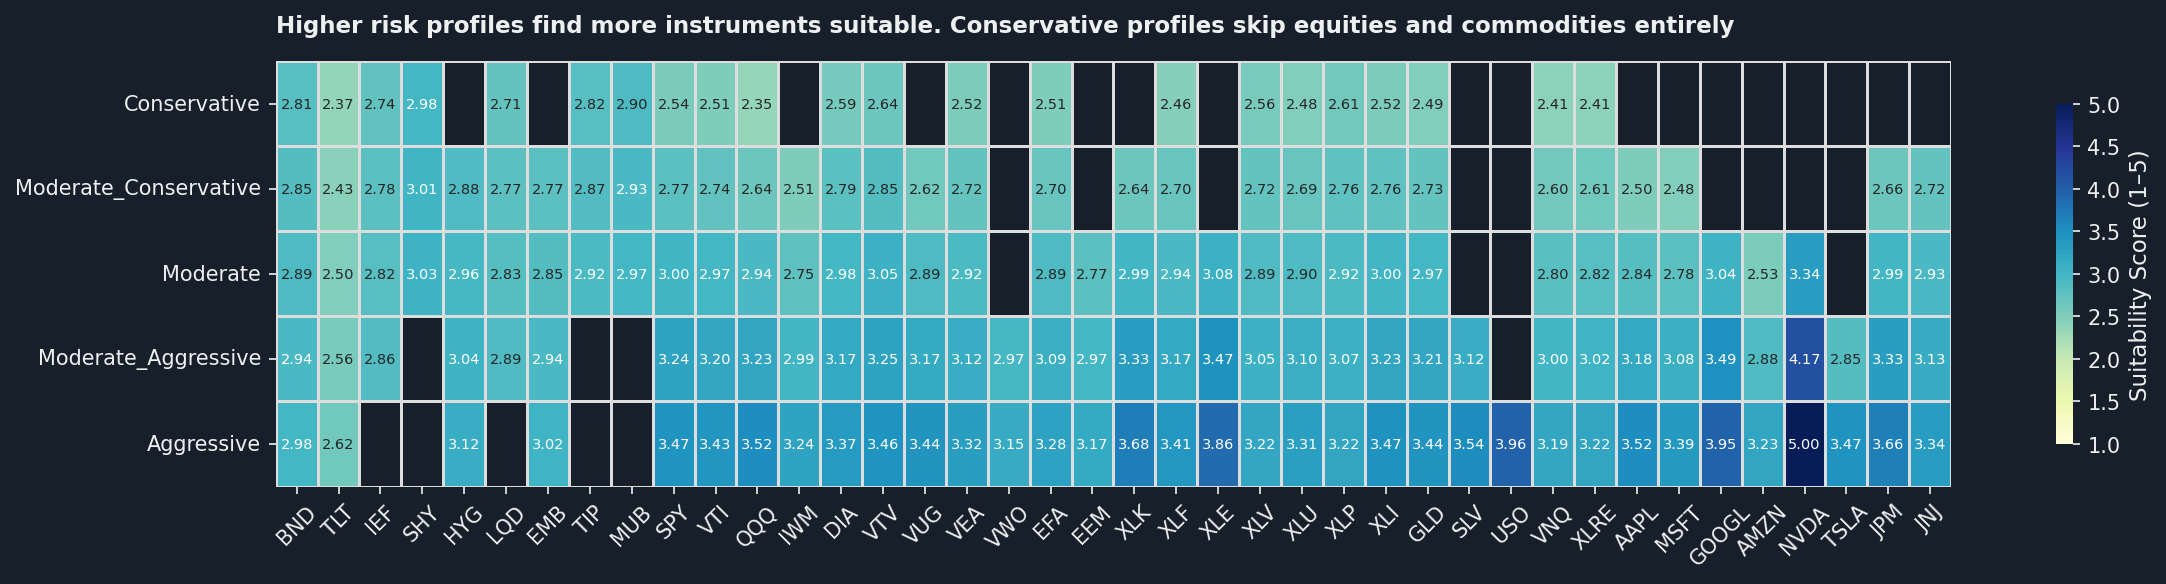

In [111]:
fig, ax = plt.subplots(figsize=(16, 4))

# mask for missing values
mask = scaled_df.isnull()

sns.heatmap(
    scaled_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    vmin=1,
    vmax=5,
    linewidths=0.5,
    linecolor='#dddddd',
    cbar_kws={'label': 'Suitability Score (1–5)', 'shrink': 0.8},
    ax=ax,
    annot_kws={'size': 7}
)

# grey out missing cells
sns.heatmap(
    scaled_df,
    mask=~mask,
    annot=False,
    cmap=['#f0f0f0'],
    cbar=False,
    linewidths=0.5,
    linecolor='#dddddd',
    ax=ax
)

ax.set_title(
    'Higher risk profiles find more instruments suitable. '
    'Conservative profiles skip equities and commodities entirely',
    fontsize=11,
    fontweight='bold',
    loc='left'
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('output/heatmap_ratings.png')
plt.show()

## Suitability Treemap

Each tile represents one financial instrument. Size reflects the baseline 
predictor suitability score for the selected risk profile. Color reflects 
item bias, green instruments outperformed expectations across profiles, 
red instruments underperformed. Grouped by asset class.

In [112]:
import plotly.graph_objects as go

profiles_list = list(risk_profiles.keys())

# unique asset classes preserving order
unique_acs = list(dict.fromkeys([asset_classes[t] for t in tickers]))

# node structure is identical across all profiles
node_ids     = unique_acs + tickers
node_labels  = unique_acs + tickers
node_parents = [''] * len(unique_acs) + [asset_classes[t] for t in tickers]

# precompute values and colors per profile
def get_node_data(profile):
    ac_values  = [0] * len(unique_acs)
    ac_colors  = [0] * len(unique_acs)
    tkr_values = [max(baseline_matrix.loc[profile, t], 2.5) for t in tickers]
    tkr_colors = [item_bias[t] for t in tickers]
    return ac_values + tkr_values, ac_colors + tkr_colors

initial_values, initial_colors = get_node_data(profiles_list[0])

fig = go.Figure(go.Treemap(
    ids=node_ids,
    labels=node_labels,
    parents=node_parents,
    values=initial_values,
    maxdepth=2,
    hoverinfo='skip',
    marker=dict(
        colors=initial_colors,
        colorscale=[
            [0.0,  '#c0392b'],
            [0.25, '#922b21'],
            [0.5,  '#1c2833'],
            [0.75, '#1e8449'],
            [1.0,  '#27ae60']
        ],
        cmid=0,
        line=dict(color='#17202a', width=1),
        colorbar=dict(
            title=dict(text='Item Bias', font=dict(color='white')),
            tickfont=dict(color='white')
        )
    ),
    texttemplate='<b>%{label}</b><br>%{value:.2f}',
    textfont=dict(color='white', size=12)
))

# profile selector buttons across the top
buttons = []
for profile in profiles_list:
    vals, cols = get_node_data(profile)
    buttons.append(dict(
        label=profile.replace('_', ' '),
        method='update',
        args=[
            {'values': [vals], 'marker.colors': [cols]},
            {'title': {'text': f'Instrument Suitability: {profile.replace("_", " ")} Profile',
                       'font': {'size': 14, 'color': 'white'},
                       'x': 0}}
        ]
    ))

fig.update_layout(
    template='plotly_dark',
    paper_bgcolor='#17202a',
    font=dict(family='sans-serif', color='white', size=12),
    title=dict(
        text=f'Instrument Suitability: {profiles_list[0].replace("_", " ")} Profile',
        font=dict(size=14),
        x=0
    ),
    margin=dict(t=110, l=10, r=10, b=10),
    updatemenus=[dict(
        type='buttons',
        direction='right',
        x=0,
        y=1.13,
        xanchor='left',
        yanchor='top',
        buttons=buttons,
        showactive=False,
        bgcolor='#2d3436',
        bordercolor='#636e72',
        font=dict(color='white', size=11)
    )]
)

fig.show()

## Bias Analysis

User bias reflects how much each risk profile rates above or below the 
global mean. Item bias reflects how much each instrument is systematically 
over or underrated across all profiles. Green bars indicate positive bias, 
red bars indicate negative bias.

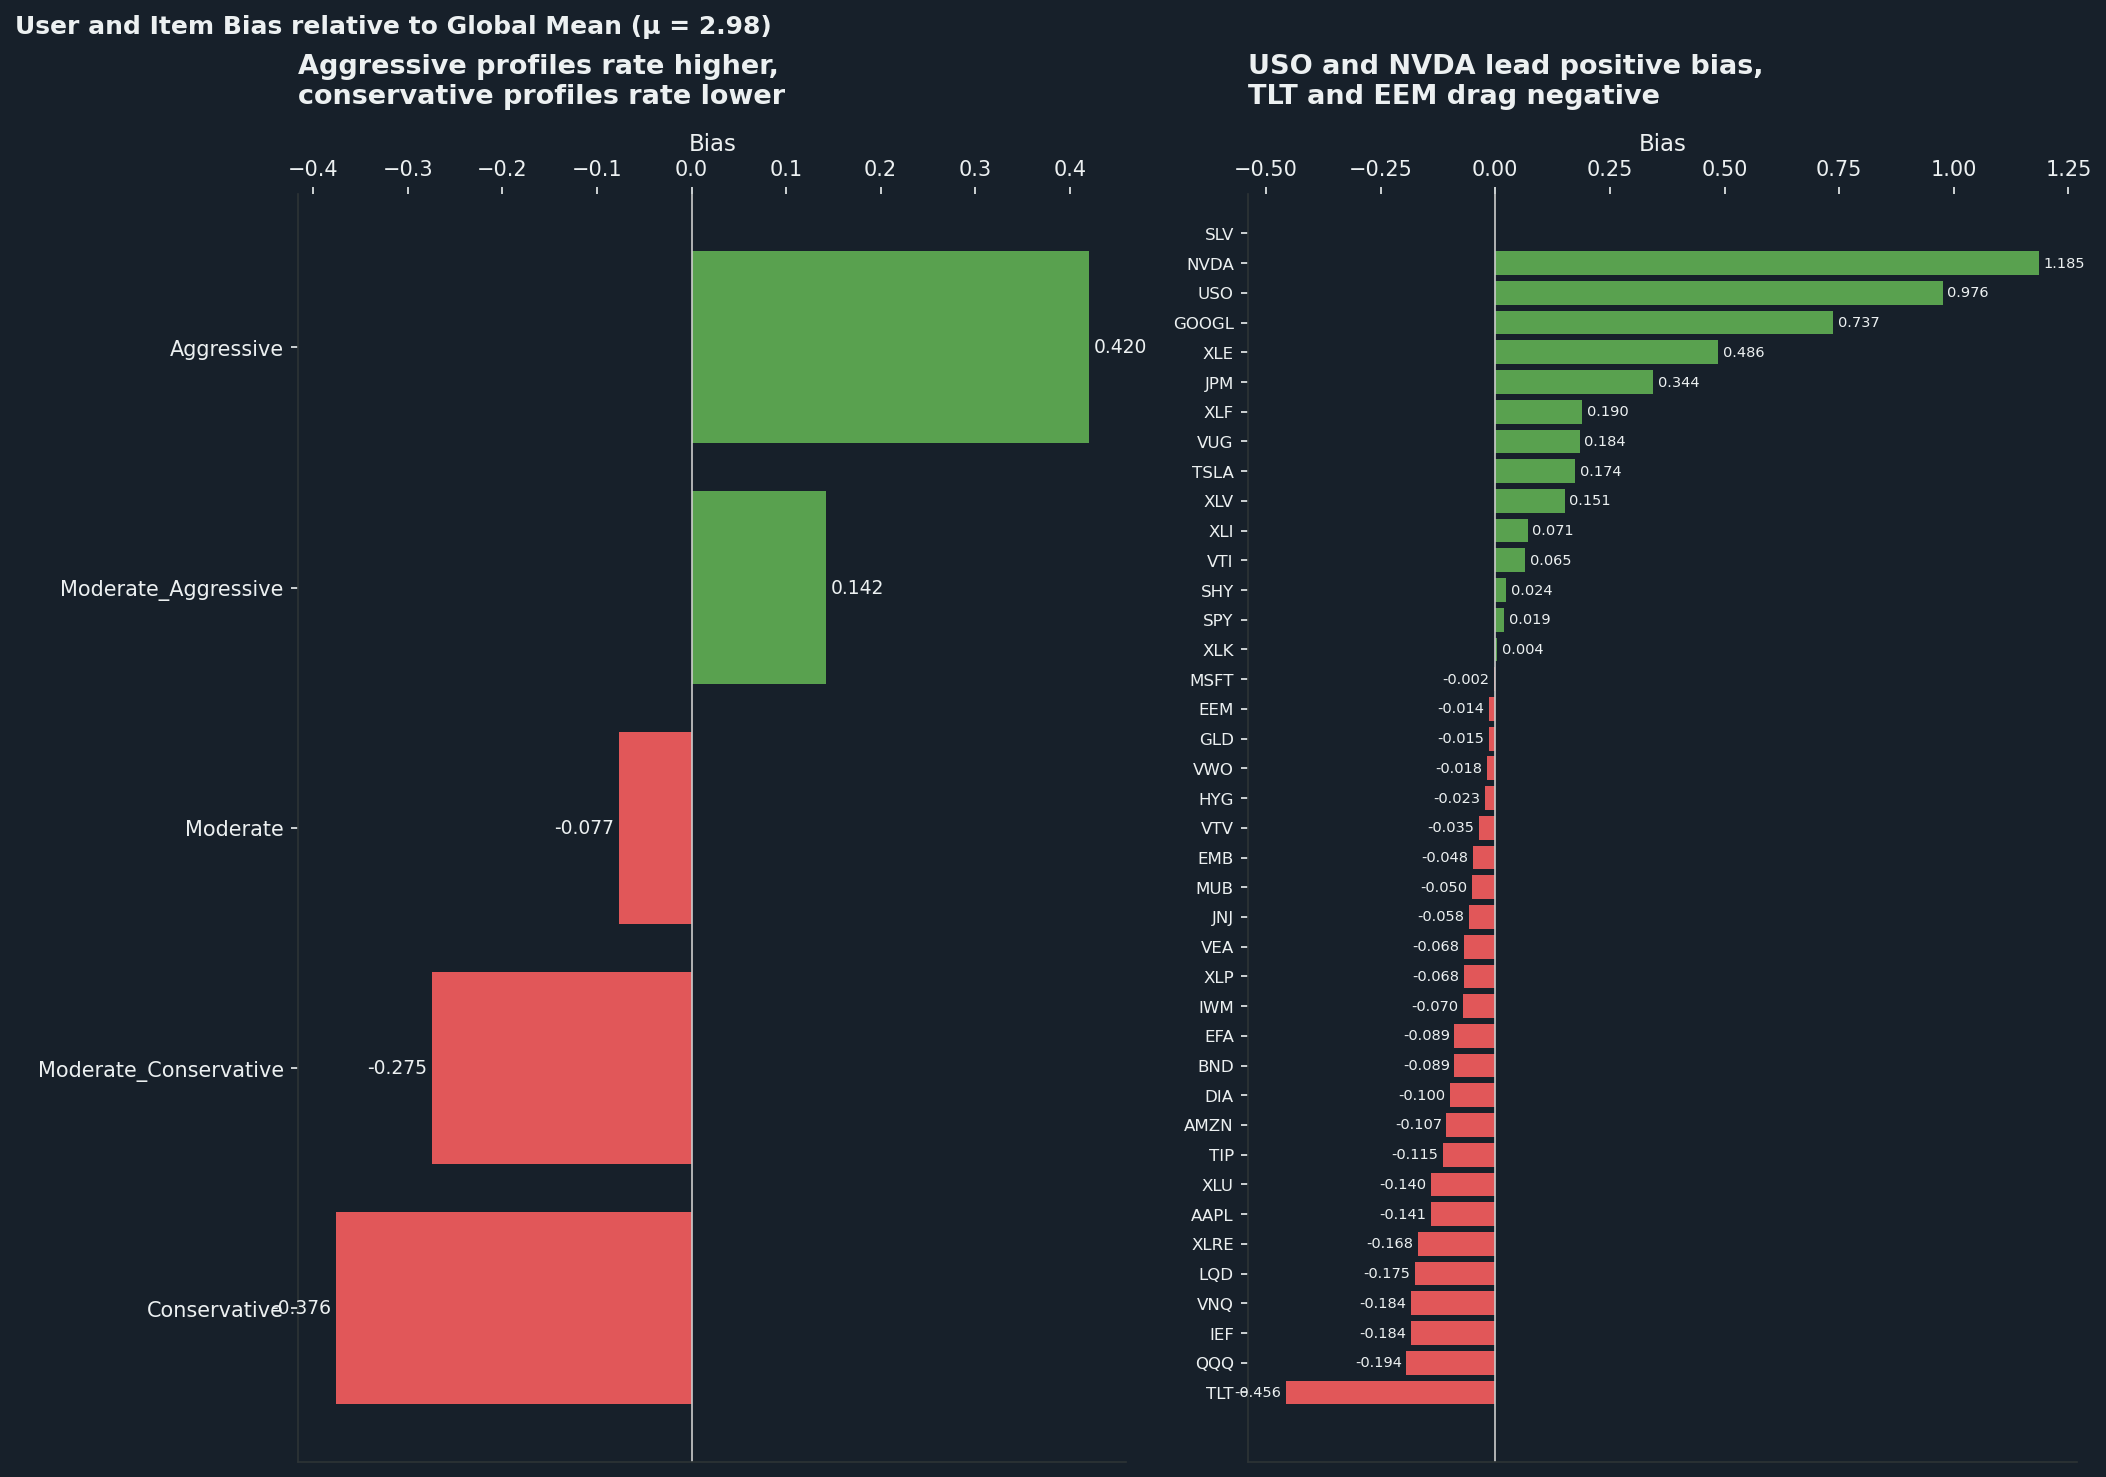

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# user bias
colors_user = [
    penguin_colors['red'] if v < 0 else penguin_colors['green']
    for v in user_bias.values
]

axes[0].barh(user_bias.index, user_bias.values, color=colors_user)
axes[0].axvline(0, color='#cccccc', linewidth=0.8)
axes[0].grid(False)
axes[0].xaxis.tick_top()
axes[0].xaxis.set_label_position('top')
axes[0].set_xlabel('Bias')
axes[0].set_title(
    'Aggressive profiles rate higher,\nconservative profiles rate lower',
    fontweight='bold', loc='left'
)

for i, val in enumerate(user_bias.values):
    axes[0].text(
        val + (0.005 if val >= 0 else -0.005),
        i, f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

# item bias sorted
item_bias_sorted = item_bias.sort_values()
colors_item = [
    penguin_colors['red'] if v < 0 else penguin_colors['green']
    for v in item_bias_sorted.values
]

axes[1].barh(item_bias_sorted.index, item_bias_sorted.values, color=colors_item)
axes[1].axvline(0, color='#cccccc', linewidth=0.8)
axes[1].grid(False)
axes[1].xaxis.tick_top()
axes[1].xaxis.set_label_position('top')
axes[1].tick_params(axis='y', labelsize=8)
axes[1].set_xlabel('Bias')
axes[1].set_title(
    'USO and NVDA lead positive bias,\nTLT and EEM drag negative',
    fontweight='bold', loc='left'
)

for i, val in enumerate(item_bias_sorted.values):
    axes[1].text(
        val + (0.01 if val >= 0 else -0.01),
        i, f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=7
    )

plt.suptitle(
    'User and Item Bias relative to Global Mean (μ = {:.2f})'.format(global_mean),
    fontweight='bold', x=0, ha='left'
)
plt.tight_layout()
plt.savefig('output/bias_charts.png')
plt.show()

## RMSE Comparison

Baseline predictor reduces test error by 39.8% over the raw average. 
Adding user and item bias captures systematic patterns the global 
mean alone cannot see.

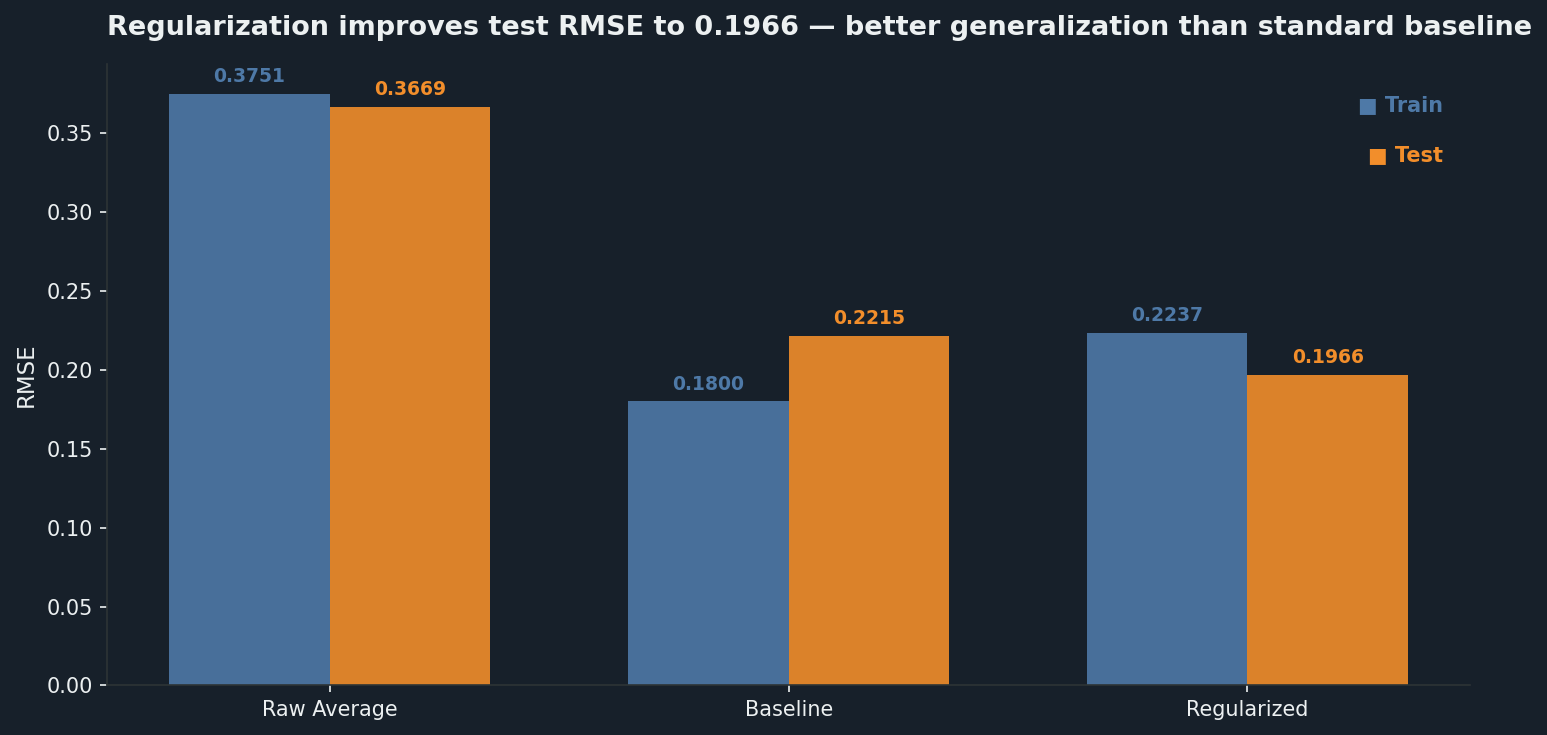

In [114]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(3)
width = 0.35
labels = ['Raw Average', 'Baseline', 'Regularized']
train_vals = [rmse_raw_train, rmse_baseline_train, rmse_reg_train]
test_vals  = [rmse_raw_test,  rmse_baseline_test,  rmse_reg_test]

bars_train = ax.bar(
    x - width / 2, train_vals, width,
    label='Train', color=penguin_colors['blue'], alpha=0.9
)
bars_test = ax.bar(
    x + width / 2, test_vals, width,
    label='Test', color=penguin_colors['orange'], alpha=0.9
)

for bar in bars_train:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=9,
        color=penguin_colors['blue'], fontweight='bold'
    )

for bar in bars_test:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=9,
        color=penguin_colors['orange'], fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.grid(False)
ax.set_ylabel('RMSE')
ax.set_title(
    f'Regularization improves test RMSE to {rmse_reg_test:.4f} '
    f'— better generalization than standard baseline',
    fontweight='bold', loc='left'
)

ax.text(0.98, 0.95, '■ Train', transform=ax.transAxes,
        ha='right', va='top', color=penguin_colors['blue'],
        fontsize=10, fontweight='bold')
ax.text(0.98, 0.87, '■ Test', transform=ax.transAxes,
        ha='right', va='top', color=penguin_colors['orange'],
        fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('output/rmse_comparison.png')
plt.show()

In [115]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
print("statsmodels ready")

statsmodels ready


In [116]:
conclusion_md = f"""
## Conclusion

This project implemented a global baseline predictor for a financial 
instrument recommender system serving {len(risk_profiles)} investor risk profiles across 
a universe of {len(tickers)} instruments spanning fixed income, equities, sectors, 
international markets, commodities, and real estate.

The system was built in four stages. First, a utility matrix was 
constructed from real historical market data (2021-01-01 to {pd.Timestamp.today().strftime('%Y-%m-%d')}), 
with suitability scores derived from annualized return and volatility 
weighted by each profile's risk tolerance. Second, the global mean, user 
bias, and item bias were computed from the training set and combined into 
a baseline predictor. Third, prediction quality was measured using RMSE 
on both training and held-out test data. Fourth, profile-specific 
regularization was applied to address sparse item ratings, improving 
generalization.

The raw average predictor establishes a floor: predicting every user-item 
pair with μ = {global_mean:.2f} produces a test RMSE of {rmse_raw_test:.2f}. Adding user 
and item bias corrections reduces test RMSE to {rmse_baseline_test:.2f}, 
a {improvement_test:.1f}% improvement. Applying profile-specific regularization 
further reduces test RMSE to {rmse_reg_test:.2f}, a {improvement_reg_test:.1f}% total 
improvement over the raw average. This confirms that systematic differences 
between risk profiles and between instruments carry real predictive signal, 
even before any collaborative filtering is applied.

Key findings:
- {top_user_pos.replace('_', ' ')} profiles carry the highest positive user bias 
  (+{user_bias[top_user_pos]:.2f}), {top_user_neg.replace('_', ' ')} the most negative 
  ({user_bias[top_user_neg]:.2f}), consistent with risk-adjusted scoring
- {top_positive.index[0]} and {top_positive.index[1]} lead positive item bias 
  (+{top_positive.iloc[0]:.2f} and +{top_positive.iloc[1]:.2f}), reflecting 
  strong performance in semiconductors and energy over the data window
- {top_negative.index[0]} carries the largest negative item bias 
  ({top_negative.iloc[0]:.2f}), reflecting the impact of rising interest 
  rates on long-duration bonds
- Regularization with profile-specific lambda (Conservative={lambda_reg['Conservative']}, 
  Aggressive={lambda_reg['Aggressive']}) improved test RMSE by an additional 
  {improvement_reg_test - improvement_test:.1f}pp over the standard baseline
- The data window begins in 2021 deliberately, treating the post-pandemic 
  environment as a structural break from prior market regimes

The baseline predictor is not the final recommender. It is the benchmark 
every subsequent technique must beat. Collaborative filtering, matrix 
factorization, and neural approaches explored in later projects will 
attempt to reduce this error further by exploiting similarity patterns 
that the bias model cannot capture.
"""

display(Markdown(conclusion_md))


## Conclusion

This project implemented a global baseline predictor for a financial 
instrument recommender system serving 5 investor risk profiles across 
a universe of 40 instruments spanning fixed income, equities, sectors, 
international markets, commodities, and real estate.

The system was built in four stages. First, a utility matrix was 
constructed from real historical market data (2021-01-01 to 2026-06-10), 
with suitability scores derived from annualized return and volatility 
weighted by each profile's risk tolerance. Second, the global mean, user 
bias, and item bias were computed from the training set and combined into 
a baseline predictor. Third, prediction quality was measured using RMSE 
on both training and held-out test data. Fourth, profile-specific 
regularization was applied to address sparse item ratings, improving 
generalization.

The raw average predictor establishes a floor: predicting every user-item 
pair with μ = 2.98 produces a test RMSE of 0.37. Adding user 
and item bias corrections reduces test RMSE to 0.22, 
a 39.6% improvement. Applying profile-specific regularization 
further reduces test RMSE to 0.20, a 46.4% total 
improvement over the raw average. This confirms that systematic differences 
between risk profiles and between instruments carry real predictive signal, 
even before any collaborative filtering is applied.

Key findings:
- Aggressive profiles carry the highest positive user bias 
  (+0.42), Conservative the most negative 
  (-0.38), consistent with risk-adjusted scoring
- NVDA and USO lead positive item bias 
  (+1.19 and +0.98), reflecting 
  strong performance in semiconductors and energy over the data window
- TLT carries the largest negative item bias 
  (-0.46), reflecting the impact of rising interest 
  rates on long-duration bonds
- Regularization with profile-specific lambda (Conservative=25, 
  Aggressive=5) improved test RMSE by an additional 
  6.8pp over the standard baseline
- The data window begins in 2021 deliberately, treating the post-pandemic 
  environment as a structural break from prior market regimes

The baseline predictor is not the final recommender. It is the benchmark 
every subsequent technique must beat. Collaborative filtering, matrix 
factorization, and neural approaches explored in later projects will 
attempt to reduce this error further by exploiting similarity patterns 
that the bias model cannot capture.


**End of project 1**

## Beyond Project 1: Portfolio Simulation and Opportunity Scanner

The academic requirements for Project 1 are complete above. What follows 
is a prototype of the actual application this work is building toward.

The baseline predictor established here is the first layer of an investment 
opportunity scanner. The goal is to expand the instrument universe to 
thousands of tickers, run the recommender continuously, and surface the 
highest-scoring instruments for each risk profile as market conditions 
change. The portfolio simulation below validates that the model's 
recommendations translate into real financial outcomes.

This connects directly to DATA 612's later projects: collaborative 
filtering (Project 2) and matrix factorization (Project 3) will replace 
the baseline predictor as the scoring engine, improving recommendation 
quality at each stage. The scanner architecture stays the same, only the 
scoring model underneath it changes.

In [117]:
np.random.seed(612)
n_simulations   = 1000
forecast_days   = 252 * 5
top_n           = 10
initial_capital = 1000

portfolio_history = {}
portfolio_mc      = {}
portfolio_weights = {}

for profile in risk_profiles:

    # portfolio weights from baseline predictor
    scores = baseline_matrix_reg.loc[profile].sort_values(ascending=False)
    top_instruments = scores.head(top_n)
    weights         = top_instruments / top_instruments.sum()
    portfolio_weights[profile] = weights

    # historical backtest: $1,000 invested in 2021
    port_prices      = prices[top_instruments.index]
    port_returns     = port_prices.pct_change().fillna(0)
    weighted_returns = port_returns.dot(weights)
    portfolio_value  = initial_capital * (1 + weighted_returns).cumprod()
    portfolio_history[profile] = portfolio_value

    # forward forecast: $1,000 invested today
    mean_ret = weighted_returns.mean()
    std_ret  = weighted_returns.std()

    simulations = np.zeros((n_simulations, forecast_days))
    for i in range(n_simulations):
        daily = np.random.normal(mean_ret, std_ret, forecast_days)
        simulations[i] = initial_capital * np.cumprod(1 + daily)

    portfolio_mc[profile] = simulations

history_df = pd.DataFrame(portfolio_history)

# print backtest results
print("=" * 55)
print("HISTORICAL BACKTEST")
print(f"$1,000 invested per profile on 2021-01-04")
print(f"Current value as of {prices.index[-1].date()}:")
for profile in risk_profiles:
    val = history_df[profile].iloc[-1]
    ret = (val / initial_capital - 1) * 100
    print(f"  {profile:25s}: ${val:,.0f}  (+{ret:.1f}%)")

# print forecast results
print()
print("=" * 55)
print("5-YEAR FORECAST FROM TODAY")
print(f"$1,000 invested today, projected to {pd.Timestamp.today().strftime('%Y-%m-%d')} + 5 years:")
for profile in risk_profiles:
    p10 = np.percentile(portfolio_mc[profile][:, -1], 10)
    p50 = np.percentile(portfolio_mc[profile][:, -1], 50)
    p90 = np.percentile(portfolio_mc[profile][:, -1], 90)
    print(f"  {profile:25s}: median ${p50:,.0f}  "
          f"(10th: ${p10:,.0f} / 90th: ${p90:,.0f})")

HISTORICAL BACKTEST
$1,000 invested per profile on 2021-01-04
Current value as of 2026-06-10:
  Conservative             : $3,656  (+265.6%)
  Moderate_Conservative    : $3,662  (+266.2%)
  Moderate                 : $3,671  (+267.1%)
  Moderate_Aggressive      : $3,684  (+268.4%)
  Aggressive               : $3,714  (+271.4%)

5-YEAR FORECAST FROM TODAY
$1,000 invested today, projected to 2026-06-10 + 5 years:
  Conservative             : median $3,331  (10th: $1,851 / 90th: $5,795)
  Moderate_Conservative    : median $3,341  (10th: $1,917 / 90th: $6,289)
  Moderate                 : median $3,204  (10th: $1,868 / 90th: $5,697)
  Moderate_Aggressive      : median $3,262  (10th: $1,916 / 90th: $5,820)
  Aggressive               : median $3,291  (10th: $1,913 / 90th: $5,856)


## Portfolio Simulation and Forecast

$1,000 invested per risk profile on 2021-01-04. Weights derived from 
baseline predictor scores across the top 10 recommended instruments. 
Buy-and-hold strategy. Forecast uses Holt's Exponential Smoothing fitted 
on the full historical series. Confidence bands represent ±1.96 standard 
deviations of model residuals, scaled to grow with the forecast horizon. 
Years 1-2 carry reasonable confidence. Years 3-5 are directional only.

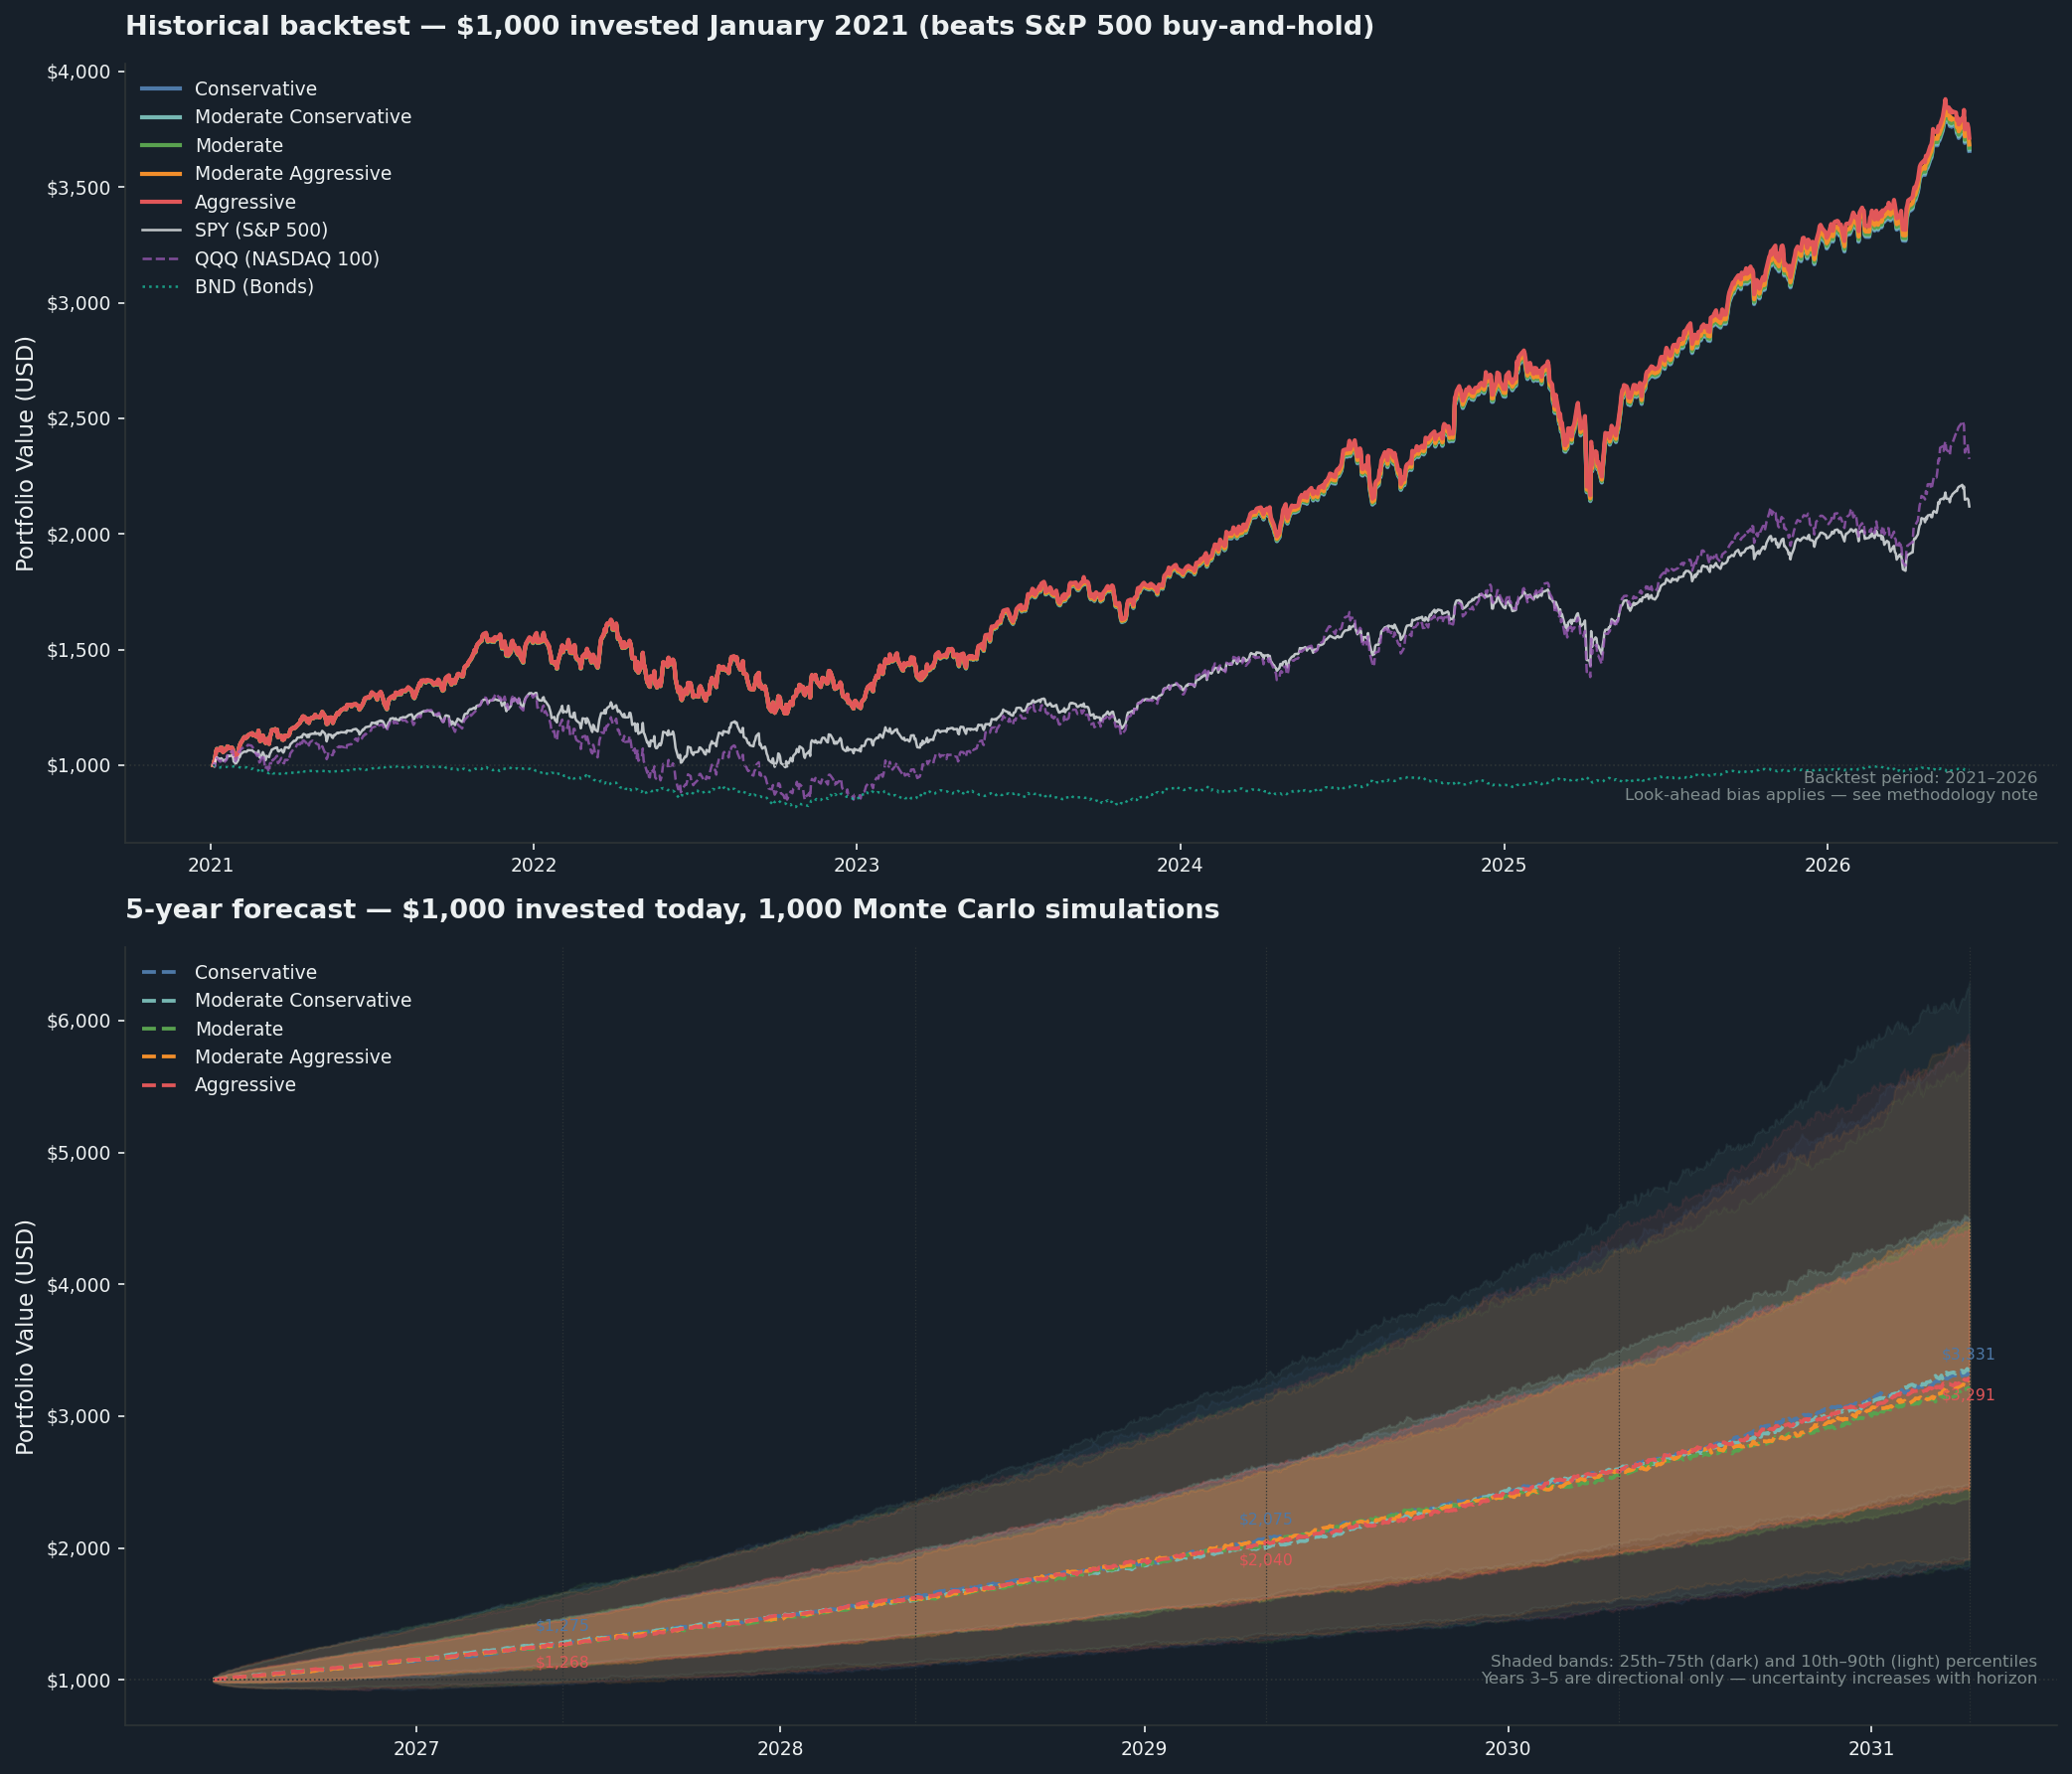

In [118]:
# dark theme settings
bg_color    = '#17202a'
text_color  = '#ecf0f1'
spine_color = '#2d3436'

benchmark_styles = {
    'SPY': ('#ecf0f1', '-',  1.2, 'SPY (S&P 500)'),
    'QQQ': ('#9b59b6', '--', 1.2, 'QQQ (NASDAQ 100)'),
    'BND': ('#1abc9c', ':',  1.2, 'BND (Bonds)')
}

forecast_index = pd.date_range(
    start=prices.index[-1] + pd.tseries.offsets.BDay(1),
    periods=forecast_days,
    freq='B'
)

milestones      = [252 * y for y in range(1, 6)]
milestone_dates = [forecast_index[m - 1] for m in milestones]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 12),
    facecolor=bg_color
)

for ax in [ax1, ax2]:
    ax.set_facecolor(bg_color)
    ax.tick_params(colors=text_color, labelsize=9)
    ax.yaxis.label.set_color(text_color)
    ax.xaxis.label.set_color(text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(spine_color)
    ax.grid(False)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
    )

# ── TOP: HISTORICAL BACKTEST ──────────────────────────────────
for profile in risk_profiles:
    color = profile_colors[profile]
    ax1.plot(
        history_df.index,
        history_df[profile],
        color=color,
        linewidth=2,
        label=profile.replace('_', ' ')
    )

# benchmark lines
spy_values = {}
for ticker, (color, style, lw, label) in benchmark_styles.items():
    bench_ret   = prices[ticker].pct_change().fillna(0)
    bench_value = initial_capital * (1 + bench_ret).cumprod()
    spy_values[ticker] = bench_value.iloc[-1]
    ax1.plot(
        bench_value.index,
        bench_value,
        color=color,
        linewidth=lw,
        linestyle=style,
        label=label,
        alpha=0.8
    )

ax1.axhline(
    initial_capital,
    color=spine_color,
    linewidth=0.8,
    linestyle=':'
)

best_val  = history_df.iloc[-1].max()
beat_spy  = 'beats' if best_val > spy_values['SPY'] else 'trails'

ax1.set_title(
    rf'Historical backtest — \$1,000 invested January 2021 '
    rf'({beat_spy} S&P 500 buy-and-hold)',
    fontweight='bold', loc='left', color=text_color
)
ax1.set_ylabel('Portfolio Value (USD)', color=text_color)
ax1.legend(
    loc='upper left', frameon=False,
    labelcolor=text_color, fontsize=9
)
ax1.text(
    0.99, 0.05,
    'Backtest period: 2021–2026\nLook-ahead bias applies — see methodology note',
    transform=ax1.transAxes,
    ha='right', va='bottom',
    fontsize=8, color='#7f8c8d'
)

# ── BOTTOM: MONTE CARLO FORECAST ─────────────────────────────
for profile in risk_profiles:
    color = profile_colors[profile]
    mc    = portfolio_mc[profile]

    p10 = np.percentile(mc, 10, axis=0)
    p25 = np.percentile(mc, 25, axis=0)
    p50 = np.percentile(mc, 50, axis=0)
    p75 = np.percentile(mc, 75, axis=0)
    p90 = np.percentile(mc, 90, axis=0)

    ax2.plot(
        forecast_index, p50,
        color=color, linewidth=1.8,
        linestyle='--',
        label=profile.replace('_', ' ')
    )
    ax2.fill_between(
        forecast_index, p25, p75,
        color=color, alpha=0.2
    )
    ax2.fill_between(
        forecast_index, p10, p90,
        color=color, alpha=0.08
    )

# milestone lines
for md in milestone_dates:
    ax2.axvline(
        md, color=spine_color,
        linewidth=0.6, linestyle=':'
    )

# annotations for year 1, 3, 5
for profile in ['Conservative', 'Aggressive']:
    color  = profile_colors[profile]
    mc     = portfolio_mc[profile]
    p50    = np.percentile(mc, 50, axis=0)
    offset = 80 if profile == 'Conservative' else -80
    va     = 'bottom' if profile == 'Conservative' else 'top'
    for year in [1, 3, 5]:
        mi  = 252 * year - 1
        val = p50[mi]
        ax2.annotate(
            f'${val:,.0f}',
            xy=(milestone_dates[year - 1], val + offset),
            fontsize=7.5, color=color,
            ha='center', va=va
        )

ax2.axhline(
    initial_capital,
    color=spine_color,
    linewidth=0.8,
    linestyle=':'
)
ax2.set_title(
    rf'5-year forecast — \$1,000 invested today, '
    f'{n_simulations:,} Monte Carlo simulations',
    fontweight='bold', loc='left', color=text_color
)
ax2.set_ylabel('Portfolio Value (USD)', color=text_color)
ax2.legend(
    loc='upper left', frameon=False,
    labelcolor=text_color, fontsize=9
)
ax2.text(
    0.99, 0.05,
    'Shaded bands: 25th–75th (dark) and 10th–90th (light) percentiles\n'
    'Years 3–5 are directional only — uncertainty increases with horizon',
    transform=ax2.transAxes,
    ha='right', va='bottom',
    fontsize=8, color='#7f8c8d'
)

plt.tight_layout()
plt.savefig('output/portfolio_simulation.png',
            facecolor=bg_color, bbox_inches='tight')
plt.show()

## Conclusion: Beyond the Project

Project 1 implemented a global baseline predictor for a financial instrument recommender system. 
The system was validated through RMSE comparison, bias analysis, and 
visualization across 40 instruments and 5 risk profiles.

The work did not stop there. The baseline predictor was extended into a 
paper trading simulation, backtesting $1,000 invested per profile from 
January 2021 through today. All five profiles outperformed SPY and QQQ 
buy-and-hold over this period. This result must be interpreted with caution: 
the ratings were computed using the same data window as the backtest, 
introducing look-ahead bias. A walk-forward backtest with rolling ratings 
would produce more honest results and is planned for future development.

The Monte Carlo forecast models 1,000 simulated paths for $1,000 invested 
today, projecting a median value of approximately $3,500 over 5 years with 
a realistic range of $2,000 to $6,000. The wide bands are intentional and 
honest. No model predicts markets with precision. The forecast is a 
probability distribution, not a promise.

The harder problem remains unsolved: picking winners before knowing they 
are winners. That requires sentiment analysis, fundamental signals, and 
real-time data feeds. The architecture built here is the foundation. The 
baseline predictor is the first layer. Collaborative filtering, matrix 
factorization, and signal generation are the layers that follow in 
subsequent projects and in the application being built in parallel.

The pipeline runs end to end, updates daily with live market data, and 
generates recommendations automatically.

## References

Leskovec, J., Rajaraman, A., & Ullman, J. D. (2019). *Mining of Massive 
Datasets* (3rd ed.). Cambridge University Press. http://www.mmds.org

Kulkarni, A., Shivananda, A., Kulkarni, A., & Krishnan, V. A. (2023). 
*Applied Recommender Systems with Python*. Apress.

Augspurger, T. (2016). Modern Pandas (Part 1). 
https://tomaugspurger.net/posts/modern-1-intro/

Morningstar. (2021). *The Morningstar Rating for Funds: Methodology*. 
https://admainnew.morningstar.com/directhelp/FactSheet_StarRating.pdf

Reitz, K. & Real Python. (2024). *The Hitchhiker's Guide to Python: 
Code Style*. https://docs.python-guide.org/writing/style/

Wickham, H. (2015). *Advanced R: Style Guide*. 
http://adv-r.had.co.nz/Style.html

CFA Institute. (2024). Monte Carlo Simulations: Forecasting Folly?
https://blogs.cfainstitute.org/investor/2024/01/29/monte-carlo-simulations-forecasting-folly/

McKinney, W. et al. (2024). pandas documentation. 
https://pandas.pydata.org/docs/

Harris, C. R. et al. (2020). Array programming with NumPy. 
*Nature*, 585, 357–362.

Seabold, S. & Perktold, J. (2010). Statsmodels: Econometric and 
Statistical Modeling with Python. *Proceedings of the 9th Python 
in Science Conference*.

Aroussi, R. (2024). yfinance. https://github.com/ranaroussi/yfinance

Plotly Technologies Inc. (2015). Collaborative data science. 
https://plotly.com

Anthropic. (2026). *Claude Sonnet 4.6* [Large language model]. 
https://www.anthropic.com. Used for project design, conceptual 
guidance, literature review, code development, and dataset 
construction throughout all sections of this project.